<div style="background: linear-gradient(135deg, #1B3A6B 0%, #2E86AB 100%); padding: 45px 30px; border-radius: 16px; text-align: center;"><h1 style="color:white; font-size:24px;">MÉMOIRE DE FIN D'ÉTUDES</h1><h2 style="color:#F18F01; font-size:20px;">Comparaison et aide à la décision dans la sélection des modèles de portefeuille</h2><p style="color:#D6EAF8; font-size:14px;">Markowitz · MEDAF · Machine Learning · Méthode AHP</p><p style="color:white; font-size:13px;"><b>Anas Haddadi</b> | Master Actuariat &amp; Finance de Marché | FSJES Aïn Sebaâ | 2025–2026</p></div>

---
## 📑 Structure du Notebook

| Chapitre | Contenu |
|----------|----------|
| **5** | Données & Méthodologie |
| **6** | Modèle de Markowitz |
| **7** | MEDAF (CAPM) |
| **8** | Machine Learning — Random Forest |
| **9** | Comparaison des Modèles (Out-of-Sample) |
| **10** | Méthode AHP — Sélection Multicritère |


---
# ⚙️ Importation des bibliothèques

> Décommenter `pip install` si nécessaire.

In [1]:
# !pip install yfinance pandas numpy matplotlib seaborn scipy scikit-learn

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy.optimize import minimize
from scipy import stats
from datetime import datetime

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
import yfinance as yf

# Palette cohérente avec le rapport
BLUE_DARK = "#1B3A6B"
BLUE_MID  = "#2E86AB"
ORANGE    = "#F18F01"
GREEN     = "#27AE60"
RED       = "#E74C3C"
PURPLE    = "#6C3483"
TEAL      = "#1ABC9C"

plt.rcParams.update({
    "figure.dpi": 130,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
})
sns.set_palette("tab10")

print("✅ Bibliothèques importées avec succès")
print(f"📅 Date d'exécution : {datetime.now().strftime('%d/%m/%Y %H:%M')}")


✅ Bibliothèques importées avec succès
📅 Date d'exécution : 04/07/2026 22:18


---
# 📘 CHAPITRE 5 — Données et Méthodologie

## 5.1 Présentation des données

Notre étude porte sur **10 actions du marché américain** (NYSE & NASDAQ), collectées via **yfinance** sur la période **janvier 2020 – janvier 2025**.

| # | Ticker | Société | Secteur |
|---|--------|---------|--------|
| 1 | AAPL | Apple Inc. | Technologie |
| 2 | MSFT | Microsoft Corp. | Technologie |
| 3 | NVDA | NVIDIA Corp. | Semi-conducteurs |
| 4 | AMZN | Amazon.com Inc. | Consommation discrétionnaire |
| 5 | KO | The Coca-Cola Co. | Consommation de base |
| 6 | JPM | JPMorgan Chase | Finance |
| 7 | JNJ | Johnson & Johnson | Santé |
| 8 | XOM | ExxonMobil Corp. | Énergie |
| 9 | BA | Boeing Co. | Industrie |
| 10 | TSLA | Tesla Inc. | Automobile/Tech |

L'indice **S&P 500 (^GSPC)** sert de proxy pour le MEDAF.


In [2]:
# ── PARAMÈTRES GLOBAUX ──────────────────────────────────────────────
TICKERS = ["AAPL", "MSFT", "NVDA", "AMZN", "KO",
           "JPM",  "JNJ",  "XOM",  "BA",   "TSLA"]

NOMS = {
    "AAPL": "Apple",   "MSFT": "Microsoft", "NVDA": "NVIDIA",
    "AMZN": "Amazon",  "KO":   "Coca-Cola",  "JPM":  "JPMorgan",
    "JNJ":  "J&J",     "XOM":  "ExxonMobil", "BA":   "Boeing",
    "TSLA": "Tesla"
}
SECTEURS = {
    "AAPL": "Tech",  "MSFT": "Tech",  "NVDA": "Tech",
    "AMZN": "Conso", "KO":   "Conso", "JPM":  "Finance",
    "JNJ":  "Santé", "XOM":  "Énergie","BA":  "Industrie",
    "TSLA": "Auto"
}

MARKET    = "^GSPC"
RF_ANNUAL = 0.045           # Taux sans risque annuel (T-Bill ~2024)
RF_DAILY  = RF_ANNUAL / 252
START     = "2020-01-01"
END       = "2025-01-01"
N_SIM     = 10_000

print(f"📌 Univers : {len(TICKERS)} actions  |  Période : {START} → {END}")
print(f"💵 Taux sans risque : {RF_ANNUAL*100:.1f}% /an  |  {RF_DAILY*100:.4f}% /jour")


📌 Univers : 10 actions  |  Période : 2020-01-01 → 2025-01-01
💵 Taux sans risque : 4.5% /an  |  0.0179% /jour


In [3]:
# ── TÉLÉCHARGEMENT DES DONNÉES (avec cache local anti-coupure) ───────
# Sécurité pour la soutenance : si Wi-Fi absent/instable ou yfinance en
# limite de requêtes, on réutilise le cache local déjà téléchargé au lieu
# de planter. Le calcul et les résultats restent identiques.
import pickle, pathlib
CACHE_FILE = pathlib.Path("cache_donnees_pfe.pkl")
tous_tickers = TICKERS + [MARKET]

raw = None
if CACHE_FILE.exists():
    try:
        with open(CACHE_FILE, "rb") as f:
            raw = pickle.load(f)
        print(f"\U0001F4E6 Données chargées depuis le cache local ({CACHE_FILE.name})")
    except Exception as e:
        print(f"\u26A0\uFE0F Cache illisible ({e}), nouveau téléchargement...")
        raw = None

if raw is None:
    print("\u23EC Téléchargement en cours...")
    try:
        raw = yf.download(tous_tickers, start=START, end=END,
                          auto_adjust=True, progress=True)
        with open(CACHE_FILE, "wb") as f:
            pickle.dump(raw, f)
        print(f"\U0001F4BE Données mises en cache dans {CACHE_FILE.name} (pour la soutenance)")
    except Exception as e:
        raise RuntimeError(
            "\u274C Téléchargement impossible et aucun cache disponible.\n"
            "-> Exécuter ce notebook au moins une fois AVANT la soutenance "
            "(avec Internet) pour créer le fichier cache_donnees_pfe.pkl.\n"
            f"Erreur d'origine : {e}"
        )

if isinstance(raw.columns, pd.MultiIndex):
    prix_all = raw["Close"]
else:
    prix_all = raw

prix_marche = prix_all[[MARKET]].copy()
# ffill(limit=1) évite de supprimer des lignes pour 1 seul NaN isolé
prix = prix_all[TICKERS].ffill(limit=1).dropna()

print(f"\n✅ Données téléchargées !")
print(f"   Période effective : {prix.index[0].date()} → {prix.index[-1].date()}")
print(f"   Nombre de jours   : {len(prix)}")
print(f"   Actions valides   : {prix.shape[1]}")
print("\n📊 Aperçu des prix de clôture (5 premières lignes) :")
display(prix.head().round(2))


⏬ Téléchargement en cours...


[*********************100%***********************]  11 of 11 completed

💾 Données mises en cache dans cache_donnees_pfe.pkl (pour la soutenance)

✅ Données téléchargées !
   Période effective : 2020-01-02 → 2024-12-31
   Nombre de jours   : 1258
   Actions valides   : 10

📊 Aperçu des prix de clôture (5 premières lignes) :


Ticker,AAPL,MSFT,NVDA,AMZN,KO,JPM,JNJ,XOM,BA,TSLA
Date,,,,,,,,,,
2020-01-02,72.33,151.83,5.96,94.90,45.14,118.43,121.94,52.95,331.35,28.68
2020-01-03,71.63,149.94,5.87,93.75,44.89,116.87,120.53,52.52,330.79,29.53
2020-01-06,72.20,150.33,5.89,95.14,44.88,116.77,120.37,52.92,331.77,30.10
2020-01-07,71.86,148.96,5.96,95.34,44.53,114.79,121.11,52.49,335.29,31.27
2020-01-08,73.02,151.33,5.98,94.60,44.62,115.68,121.09,51.70,329.41,32.81


## 5.2 Prétraitement des données

In [4]:
# ── LOG-RENDEMENTS ──────────────────────────────────────────────────
# r_t = ln(P_t / P_{t-1}) — additivité temporelle, meilleure normalité
rendements      = np.log(prix / prix.shift(1)).dropna()
rend_marche_raw = np.log(prix_marche / prix_marche.shift(1)).dropna()
rend_marche     = rend_marche_raw[MARKET].reindex(rendements.index).dropna()
rendements      = rendements.loc[rend_marche.index]

print("🔍 VÉRIFICATION DES DONNÉES MANQUANTES")
na_count = rendements.isna().sum()
if na_count.sum() == 0:
    print("✅ Aucune valeur manquante.")
else:
    print(f"⚠️  {na_count.sum()} valeurs manquantes :\n{na_count[na_count > 0]}")

print("\n📊 Statistiques descriptives des rendements journaliers :")
desc = rendements.describe()
desc.loc["mean (ann.)"] = rendements.mean() * 252
desc.loc["std (ann.)"]  = rendements.std()  * np.sqrt(252)
display(desc.round(5))


🔍 VÉRIFICATION DES DONNÉES MANQUANTES
✅ Aucune valeur manquante.

📊 Statistiques descriptives des rendements journaliers :


Ticker,AAPL,MSFT,NVDA,AMZN,KO,JPM,JNJ,XOM,BA,TSLA
count,1257.00000,1257.00000,1257.00000,1257.00000,1257.00000,1257.00000,1257.00000,1257.00000,1257.00000,1257.00000
mean,0.00098,0.00080,0.00248,0.00067,0.00022,0.00054,0.00010,0.00052,-0.00050,0.00210
std,0.01994,0.01923,0.03371,0.02265,0.01317,0.02044,0.01236,0.02166,0.03227,0.04221
min,-0.13771,-0.15945,-0.20398,-0.15140,-0.10173,-0.16211,-0.07578,-0.13039,-0.27244,-0.23652
25%,-0.00846,-0.00821,-0.01612,-0.01115,-0.00533,-0.00845,-0.00574,-0.01100,-0.01471,-0.02025
50%,0.00119,0.00111,0.00329,0.00078,0.00078,0.00071,0.00012,0.00023,-0.00042,0.00187
75%,0.01192,0.01088,0.02206,0.01287,0.00619,0.00985,0.00590,0.01201,0.01342,0.02349
max,0.11316,0.13293,0.21809,0.12695,0.06278,0.16562,0.07694,0.11944,0.21768,0.19819
mean (ann.),0.24769,0.20234,0.62405,0.16800,0.05596,0.13523,0.02595,0.13219,-0.12570,0.53020
std (ann.),0.31654,0.30523,0.53517,0.35959,0.20901,0.32449,0.19615,0.34389,0.51227,0.66999


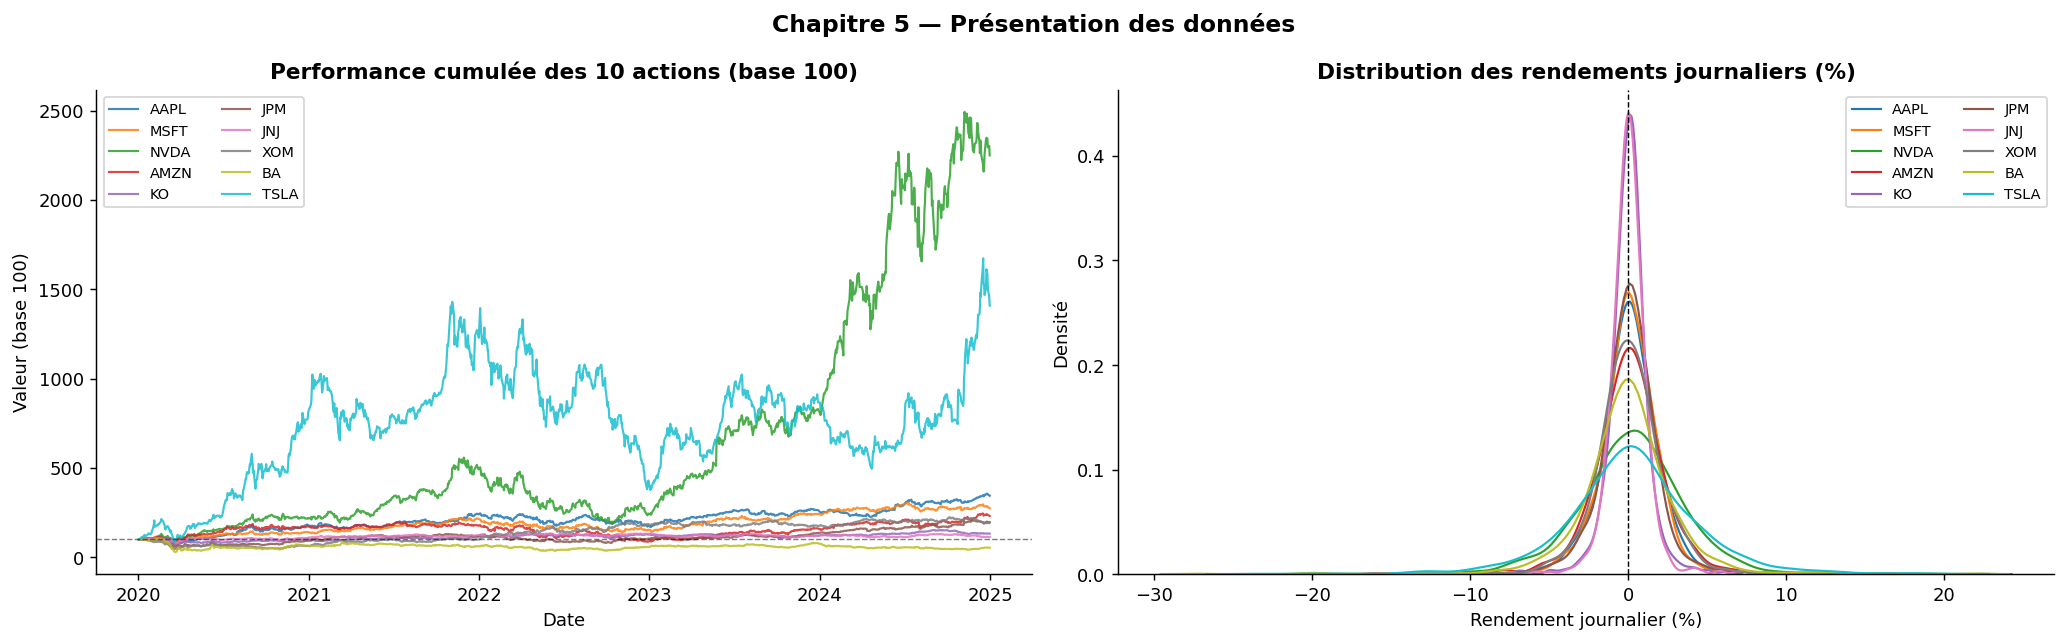

💾 Figure sauvegardée : fig_chap5_donnees.png


In [5]:
# ── VISUALISATION : Prix normalisés & distributions ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Chapitre 5 — Présentation des données", fontsize=13, fontweight="bold")

ax = axes[0]
normalises = (prix / prix.iloc[0]) * 100
for t in TICKERS:
    ax.plot(normalises.index, normalises[t], label=t, linewidth=1.2, alpha=0.85)
ax.axhline(100, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_title("Performance cumulée des 10 actions (base 100)", fontweight="bold")
ax.set_ylabel("Valeur (base 100)")
ax.legend(ncol=2, fontsize=8, loc="upper left")
ax.set_xlabel("Date")

ax = axes[1]
for t in TICKERS:
    sns.kdeplot(rendements[t] * 100, ax=ax, label=t, linewidth=1.2)
ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("Distribution des rendements journaliers (%)", fontweight="bold")
ax.set_xlabel("Rendement journalier (%)")
ax.set_ylabel("Densité")
ax.legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.savefig("fig_chap5_donnees.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Figure sauvegardée : fig_chap5_donnees.png")


## 5.3 Outils utilisés

| Outil | Utilisation |
|-------|-------------|
| **Python 3.10+** | Langage principal |
| **yfinance** | Collecte des données financières |
| **Pandas / NumPy** | Manipulation et calculs matriciels |
| **SciPy** | Optimisation SLSQP, statistiques |
| **Matplotlib / Seaborn** | Visualisation |
| **Scikit-learn** | Random Forest, évaluation ML |


---
# 📘 CHAPITRE 6 — Application du Modèle de Markowitz

## 6.1 Rendements moyens annualisés

   TABLEAU 6.1 — Rendements et Risques Annualisés (2020–2025)


,Rendement Moyen Journalier (%),Rendement Annualisé (%),Volatilité Annualisée (%),Ratio de Sharpe
Ticker,,,,
NVDA,0.2476,62.40,53.52,1.082
TSLA,0.2104,53.02,67.00,0.724
AAPL,0.0983,24.77,31.65,0.640
MSFT,0.0803,20.23,30.52,0.515
AMZN,0.0667,16.80,35.96,0.342
JPM,0.0537,13.52,32.45,0.278
XOM,0.0525,13.22,34.39,0.254
KO,0.0222,5.60,20.90,0.052
JNJ,0.0103,2.59,19.62,-0.097


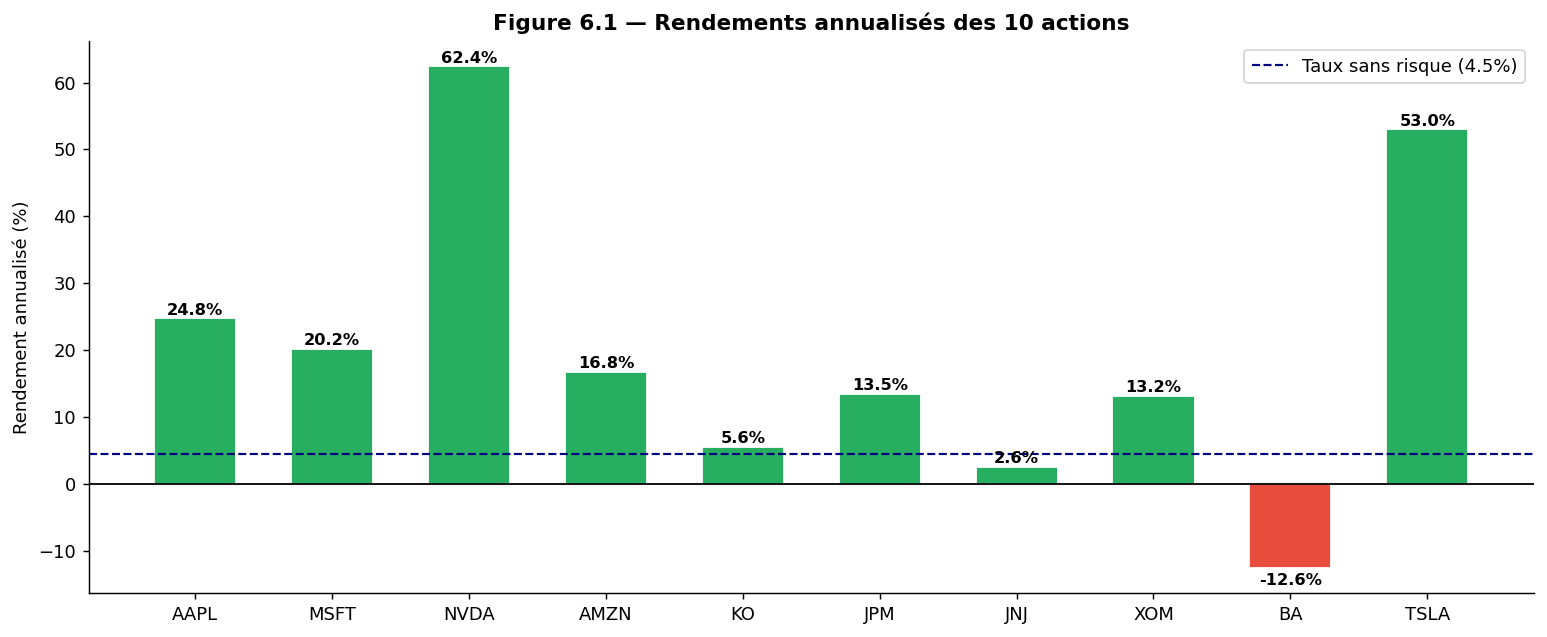

💾 Figure sauvegardée : fig_chap6_rendements.png


In [6]:
mu_journalier = rendements.mean()
mu_annualise  = mu_journalier * 252
vol_annualise = rendements.std() * np.sqrt(252)

df_rend = pd.DataFrame({
    "Rendement Moyen Journalier (%)": (mu_journalier * 100).round(4),
    "Rendement Annualisé (%)":        (mu_annualise  * 100).round(2),
    "Volatilité Annualisée (%)":      (vol_annualise * 100).round(2),
    "Ratio de Sharpe": ((mu_annualise - RF_ANNUAL) / vol_annualise).round(3)
})

print("=" * 65)
print("   TABLEAU 6.1 — Rendements et Risques Annualisés (2020–2025)")
print("=" * 65)
display(df_rend.sort_values("Rendement Annualisé (%)", ascending=False))

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#27AE60" if v > 0 else "#E74C3C" for v in mu_annualise * 100]
bars   = ax.bar(TICKERS, mu_annualise * 100, color=colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, mu_annualise * 100):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (0.5 if val >= 0 else -2.5),
            f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")
ax.axhline(0, color="black", linewidth=1)
ax.axhline(RF_ANNUAL*100, color="navy", linestyle="--", linewidth=1.2,
           label=f"Taux sans risque ({RF_ANNUAL*100:.1f}%)")
ax.set_title("Figure 6.1 — Rendements annualisés des 10 actions", fontsize=12, fontweight="bold")
ax.set_ylabel("Rendement annualisé (%)")
ax.legend()
plt.tight_layout()
plt.savefig("fig_chap6_rendements.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Figure sauvegardée : fig_chap6_rendements.png")


## 6.2 Matrice de covariance et de corrélation

TABLEAU 6.2a — Matrice de Covariance Annualisée (×10⁻⁴)


Ticker,AAPL,MSFT,NVDA,AMZN,KO,JPM,JNJ,XOM,BA,TSLA
Ticker,,,,,,,,,,
AAPL,1001.98,725.52,1041.24,677.00,293.83,425.56,232.79,313.65,674.32,1044.44
MSFT,725.52,931.67,1124.46,746.54,278.65,420.27,225.68,260.93,591.70,932.72
NVDA,1041.24,1124.46,2864.05,1129.18,247.90,576.98,156.65,345.04,931.57,1709.89
AMZN,677.00,746.54,1129.18,1293.04,168.19,314.13,126.82,167.86,525.28,1051.78
KO,293.83,278.65,247.90,168.19,436.85,361.44,241.83,309.97,486.23,240.48
JPM,425.56,420.27,576.98,314.13,361.44,1052.92,261.51,638.63,966.33,613.55
JNJ,232.79,225.68,156.65,126.82,241.83,261.51,384.75,203.27,266.71,113.20
XOM,313.65,260.93,345.04,167.86,309.97,638.63,203.27,1182.58,854.50,350.68
BA,674.32,591.70,931.57,525.28,486.23,966.33,266.71,854.50,2624.22,1123.33


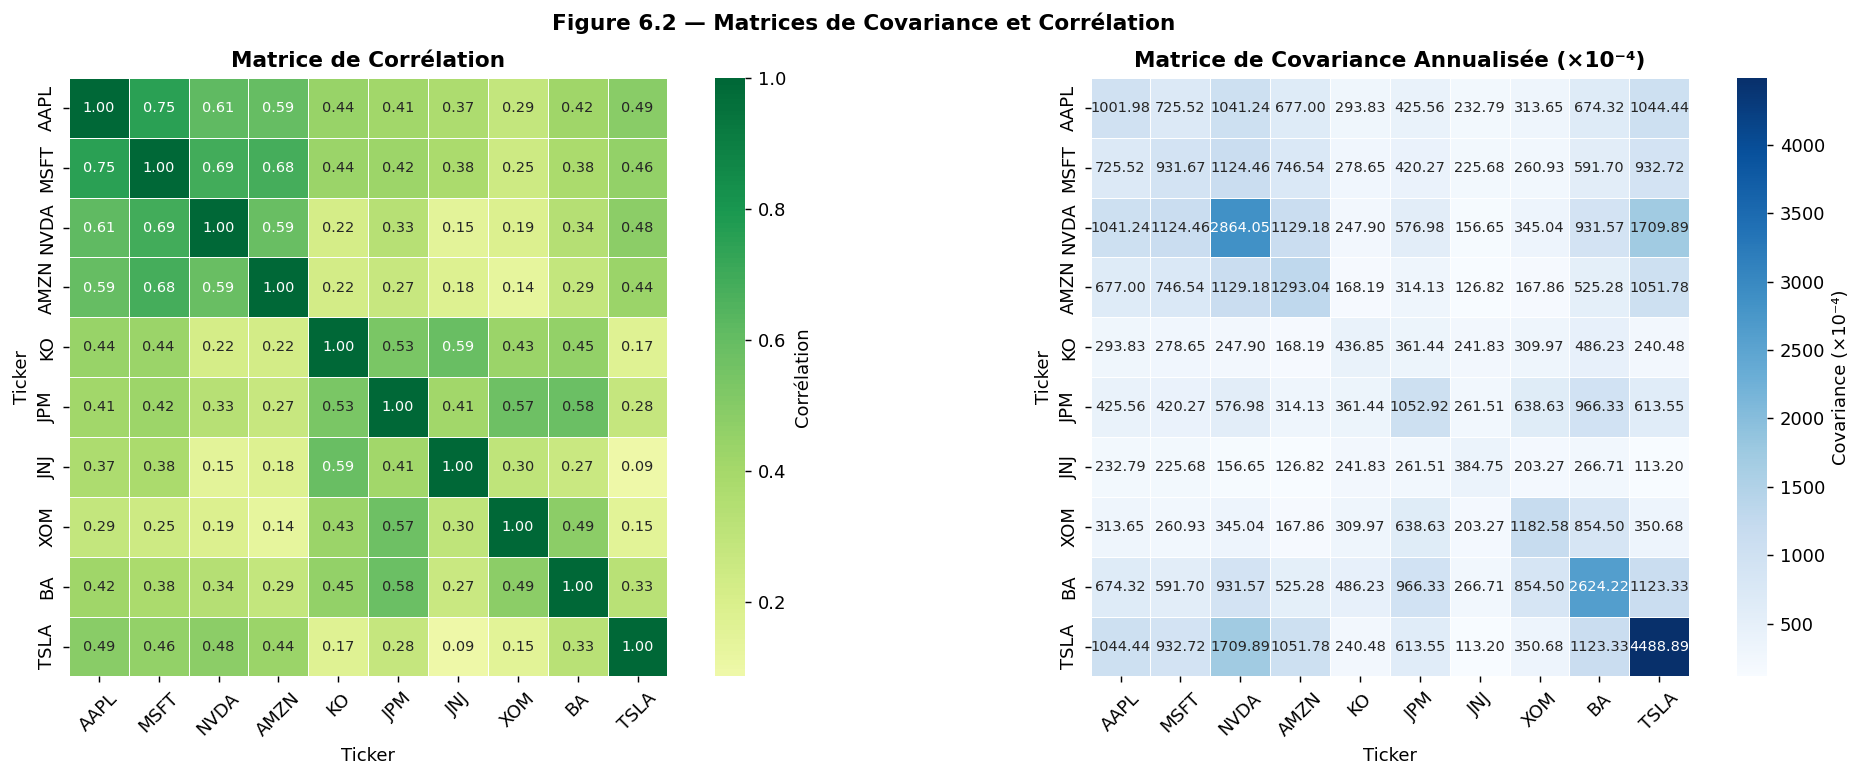

💾 Figure sauvegardée : fig_chap6_covariance.png

📊 5 paires les plus corrélées :


Corrélation
Ticker Ticker             
AAPL   MSFT         0.7509
MSFT   NVDA         0.6884
       AMZN         0.6802
AAPL   NVDA         0.6147
       AMZN         0.5948


📊 5 paires les moins corrélées :


,,Corrélation
Ticker,Ticker,
KO,TSLA,0.1717
XOM,TSLA,0.1522
NVDA,JNJ,0.1492
AMZN,XOM,0.1357
JNJ,TSLA,0.0861


In [7]:
cov_journaliere = rendements.cov()
cov_annuelle    = cov_journaliere * 252
corr_matrix     = rendements.corr()

print("TABLEAU 6.2a — Matrice de Covariance Annualisée (×10⁻⁴)")
display((cov_annuelle * 10000).round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Figure 6.2 — Matrices de Covariance et Corrélation", fontsize=12, fontweight="bold")

sns.heatmap(corr_matrix, ax=axes[0], cmap="RdYlGn", center=0,
            annot=True, fmt=".2f", linewidths=0.5, square=True,
            cbar_kws={"label": "Corrélation"}, annot_kws={"size": 8})
axes[0].set_title("Matrice de Corrélation", fontweight="bold")
axes[0].tick_params(axis="x", rotation=45)

sns.heatmap(cov_annuelle * 10000, ax=axes[1], cmap="Blues",
            annot=True, fmt=".2f", linewidths=0.5, square=True,
            cbar_kws={"label": "Covariance (×10⁻⁴)"}, annot_kws={"size": 8})
axes[1].set_title("Matrice de Covariance Annualisée (×10⁻⁴)", fontweight="bold")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("fig_chap6_covariance.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Figure sauvegardée : fig_chap6_covariance.png")

corr_pairs = (corr_matrix
              .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
              .stack().sort_values(ascending=False))
print("\n📊 5 paires les plus corrélées :")
display(corr_pairs.head(5).rename("Corrélation").round(4).to_frame())
print("\n📊 5 paires les moins corrélées :")
display(corr_pairs.tail(5).rename("Corrélation").round(4).to_frame())


## 6.3 Simulation Monte Carlo & 6.4 Frontière efficiente

In [8]:
# ── FONCTIONS MARKOWITZ ─────────────────────────────────────────────
def perf_portefeuille(poids, mu, cov, rf=RF_DAILY):
    rend   = np.dot(poids, mu) * 252
    vol    = np.sqrt(poids @ cov @ poids) * np.sqrt(252)
    sharpe = (rend - rf * 252) / vol if vol > 0 else 0.0
    return rend, vol, sharpe


def optimiser(mu, cov, objectif="sharpe", rend_cible=None, rf=RF_DAILY):
    n = len(mu)
    contraintes = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]
    bornes = tuple((0, 1) for _ in range(n))
    w0 = np.full(n, 1 / n)

    if objectif == "sharpe":
        f = lambda w: -perf_portefeuille(w, mu, cov, rf)[2]
    elif objectif == "min_variance":
        f = lambda w:  perf_portefeuille(w, mu, cov, rf)[1]
    elif objectif == "cible":
        contraintes.append({"type": "eq",
                            "fun": lambda w: np.dot(w, mu) * 252 - rend_cible})
        f = lambda w: perf_portefeuille(w, mu, cov, rf)[1]
    else:
        raise ValueError(f"Objectif inconnu : {objectif}")

    return minimize(f, w0, method="SLSQP", bounds=bornes,
                    constraints=contraintes,
                    options={"maxiter": 2000, "ftol": 1e-14})


# ── SIMULATION MONTE CARLO ──────────────────────────────────────────
np.random.seed(42)
n = len(TICKERS)
sim_rend, sim_vol, sim_sharpe, sim_poids = [], [], [], []

for _ in range(N_SIM):
    w = np.random.dirichlet(np.ones(n))
    r, v, s = perf_portefeuille(w, mu_journalier, cov_journaliere)
    sim_rend.append(r * 100)
    sim_vol.append(v * 100)
    sim_sharpe.append(s)
    sim_poids.append(w)

sim_rend   = np.array(sim_rend)
sim_vol    = np.array(sim_vol)
sim_sharpe = np.array(sim_sharpe)

print(f"✅ {N_SIM:,} portefeuilles simulés")
print(f"   Rendement  → min : {sim_rend.min():.2f}%  |  max : {sim_rend.max():.2f}%")
print(f"   Volatilité → min : {sim_vol.min():.2f}%   |  max : {sim_vol.max():.2f}%")
print(f"   Sharpe     → min : {sim_sharpe.min():.3f}  |  max : {sim_sharpe.max():.3f}")


✅ 10,000 portefeuilles simulés
   Rendement  → min : -2.47%  |  max : 48.41%
   Volatilité → min : 17.88%   |  max : 48.44%
   Sharpe     → min : -0.212  |  max : 1.053


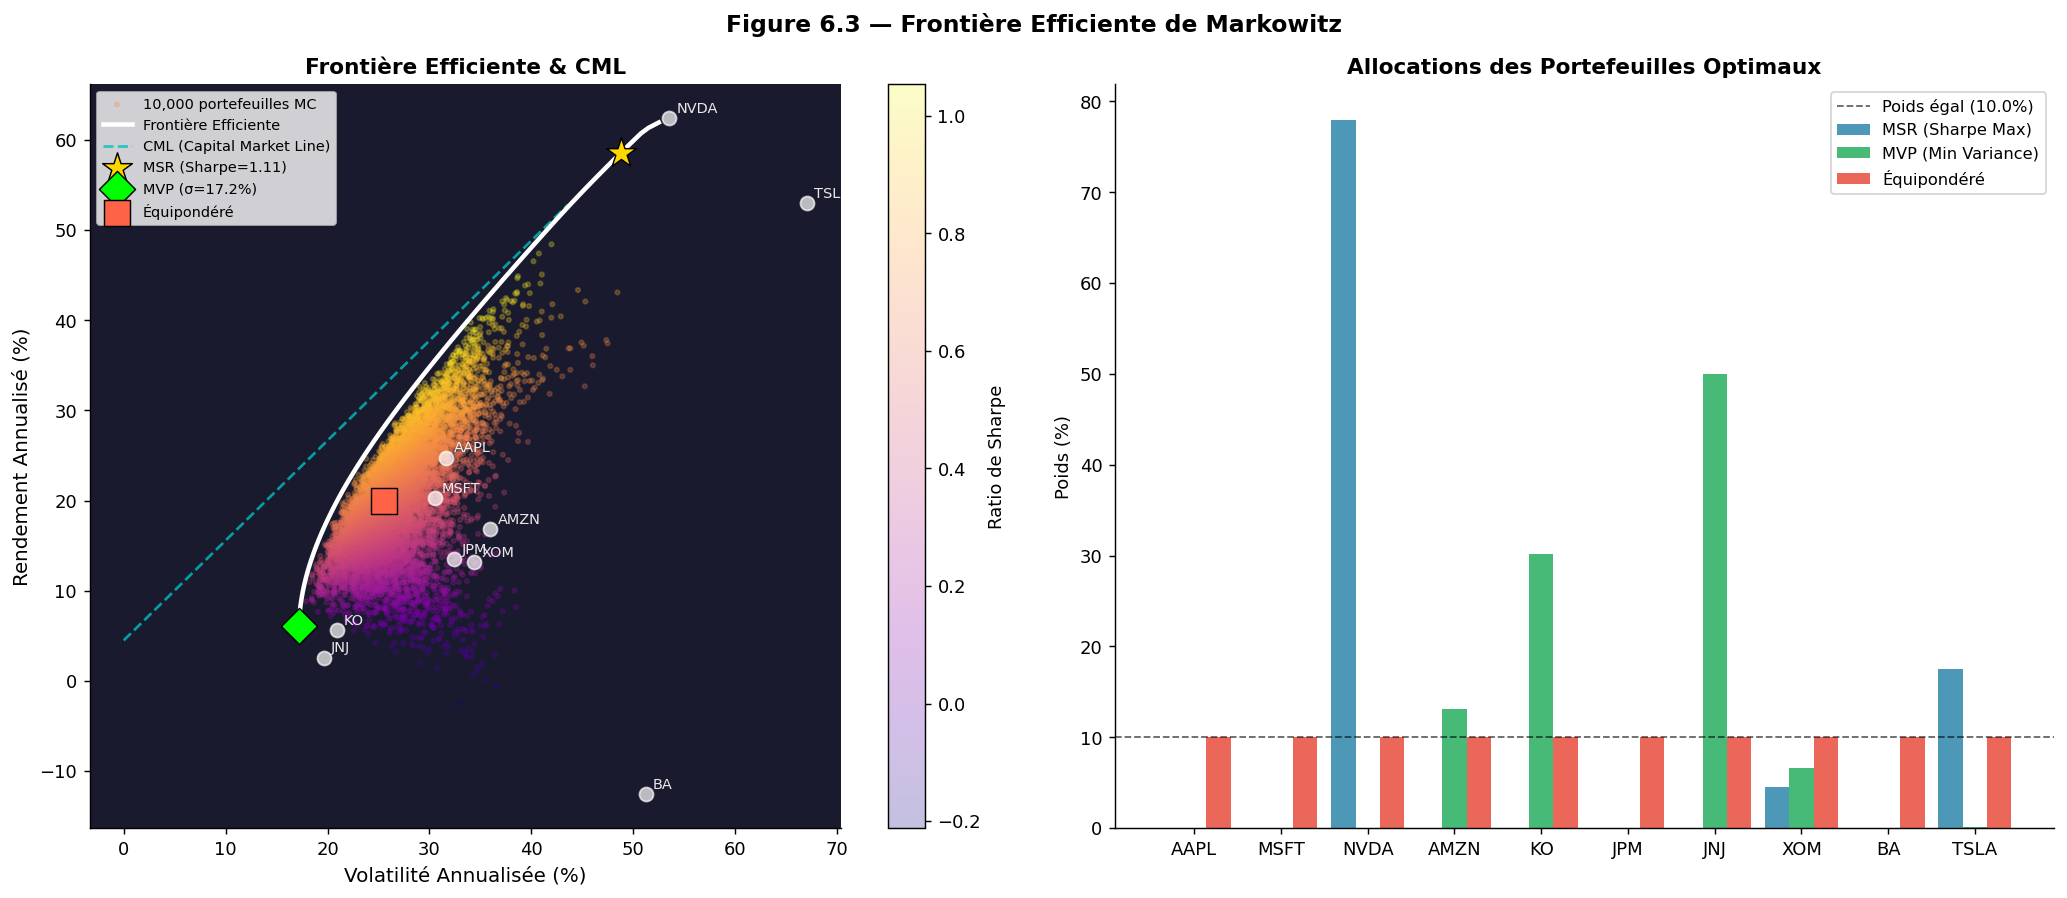

💾 Figure sauvegardée : fig_chap6_frontiere.png


In [9]:
# ── OPTIMISATION DES PORTEFEUILLES CLÉS ─────────────────────────────
res_sharpe = optimiser(mu_journalier, cov_journaliere, "sharpe")
poids_msr  = res_sharpe.x
perf_msr   = perf_portefeuille(poids_msr, mu_journalier, cov_journaliere)

res_mvp   = optimiser(mu_journalier, cov_journaliere, "min_variance")
poids_mvp = res_mvp.x
perf_mvp  = perf_portefeuille(poids_mvp, mu_journalier, cov_journaliere)

poids_eq = np.full(n, 1 / n)
perf_eq  = perf_portefeuille(poids_eq, mu_journalier, cov_journaliere)

# Frontière efficiente (100 points)
rend_min = perf_mvp[0]
rend_max = max(mu_journalier * 252) * 1.05
cibles   = np.linspace(rend_min, rend_max, 100)
front_vol, front_rend = [], []
for rc in cibles:
    res = optimiser(mu_journalier, cov_journaliere, "cible", rend_cible=rc)
    if res.success:
        r, v, _ = perf_portefeuille(res.x, mu_journalier, cov_journaliere)
        front_vol.append(v * 100)
        front_rend.append(r * 100)

# ── GRAPHIQUE FRONTIÈRE EFFICIENTE ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Figure 6.3 — Frontière Efficiente de Markowitz", fontsize=13, fontweight="bold")

ax = axes[0]
sc = ax.scatter(sim_vol, sim_rend, c=sim_sharpe, cmap="plasma",
                alpha=0.25, s=6, label=f"{N_SIM:,} portefeuilles MC")
plt.colorbar(sc, ax=ax, label="Ratio de Sharpe")
ax.plot(front_vol, front_rend, "white", linewidth=2.5, label="Frontière Efficiente", zorder=6)

rf_pct = RF_ANNUAL * 100
slope  = (perf_msr[0]*100 - rf_pct) / (perf_msr[1]*100)
x_cml  = np.linspace(0, max(sim_vol) * 0.9, 200)
ax.plot(x_cml, rf_pct + slope * x_cml, "c--",
        linewidth=1.5, alpha=0.8, label="CML (Capital Market Line)", zorder=5)

ax.scatter(perf_msr[1]*100, perf_msr[0]*100, color="gold", s=300, zorder=10,
           marker="*", edgecolors="black", linewidth=0.8,
           label=f"MSR (Sharpe={perf_msr[2]:.2f})")
ax.scatter(perf_mvp[1]*100, perf_mvp[0]*100, color="lime", s=200, zorder=10,
           marker="D", edgecolors="black", linewidth=0.8,
           label=f"MVP (σ={perf_mvp[1]*100:.1f}%)")
ax.scatter(perf_eq[1]*100, perf_eq[0]*100, color="tomato", s=200, zorder=10,
           marker="s", edgecolors="black", linewidth=0.8, label="Équipondéré")

for t in TICKERS:
    r = mu_journalier[t] * 252 * 100
    v = rendements[t].std() * np.sqrt(252) * 100
    ax.scatter(v, r, color="white", s=60, zorder=8, alpha=0.7)
    ax.annotate(t, (v, r), xytext=(4, 3), textcoords="offset points",
                fontsize=8, color="white", alpha=0.9)

ax.set_xlabel("Volatilité Annualisée (%)", fontsize=11)
ax.set_ylabel("Rendement Annualisé (%)", fontsize=11)
ax.set_title("Frontière Efficiente & CML", fontweight="bold")
ax.legend(fontsize=8, loc="upper left")
ax.set_facecolor("#1a1a2e")

ax2 = axes[1]
x   = np.arange(n)
w   = 0.28
ax2.bar(x - w, poids_msr * 100, w, label="MSR (Sharpe Max)",   color=BLUE_MID, alpha=0.85)
ax2.bar(x,     poids_mvp * 100, w, label="MVP (Min Variance)", color=GREEN,    alpha=0.85)
ax2.bar(x + w, poids_eq  * 100, w, label="Équipondéré",        color=RED,      alpha=0.85)
ax2.axhline(100/n, color="black", linestyle="--", linewidth=1, alpha=0.6,
            label=f"Poids égal ({100/n:.1f}%)")
ax2.set_xticks(x); ax2.set_xticklabels(TICKERS)
ax2.set_ylabel("Poids (%)")
ax2.set_title("Allocations des Portefeuilles Optimaux", fontweight="bold")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("fig_chap6_frontiere.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Figure sauvegardée : fig_chap6_frontiere.png")


## 6.5 Analyse des résultats

In [10]:
df_markowitz = pd.DataFrame({
    "Portefeuille": ["MSR (Sharpe Max)", "MVP (Min Variance)", "Équipondéré"],
    "Rendement Ann. (%)":  [round(p[0]*100, 2) for p in [perf_msr, perf_mvp, perf_eq]],
    "Volatilité Ann. (%)": [round(p[1]*100, 2) for p in [perf_msr, perf_mvp, perf_eq]],
    "Ratio de Sharpe":     [round(p[2], 3)     for p in [perf_msr, perf_mvp, perf_eq]],
})
for i, t in enumerate(TICKERS):
    df_markowitz[f"{t} (%)"] = [round(poids_msr[i]*100, 1),
                                 round(poids_mvp[i]*100, 1),
                                 round(poids_eq[i]*100,  1)]
df_markowitz = df_markowitz.set_index("Portefeuille")

print("=" * 70)
print("  TABLEAU 6.5 — Résultats des Portefeuilles de Markowitz")
print("=" * 70)
display(df_markowitz)

print(f"""
📝 INTERPRÉTATION :
• MSR : Sharpe = {perf_msr[2]:.3f}  — meilleur compromis risque/rendement.
• MVP : Volatilité = {perf_mvp[1]*100:.2f}%  — solution pour investisseurs prudents.
• Équipondéré : Sharpe = {perf_eq[2]:.3f}  — sous-optimal selon Markowitz.
""")


  TABLEAU 6.5 — Résultats des Portefeuilles de Markowitz


,Rendement Ann. (%),Volatilité Ann. (%),Ratio de Sharpe,AAPL (%),MSFT (%),NVDA (%),AMZN (%),KO (%),JPM (%),JNJ (%),XOM (%),BA (%),TSLA (%)
Portefeuille,,,,,,,,,,,,,
MSR (Sharpe Max),58.55,48.77,1.108,0.0,0.0,78.0,0.0,0.0,0.0,0.0,4.5,0.0,17.5
MVP (Min Variance),6.12,17.19,0.094,0.0,0.0,0.0,13.1,30.2,0.0,50.0,6.6,0.0,0.1
Équipondéré,19.96,25.54,0.605,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0



📝 INTERPRÉTATION :
• MSR : Sharpe = 1.108  — meilleur compromis risque/rendement.
• MVP : Volatilité = 17.19%  — solution pour investisseurs prudents.
• Équipondéré : Sharpe = 0.605  — sous-optimal selon Markowitz.



---
# 📘 CHAPITRE 7 — Application du MEDAF (CAPM)

## 7.1 Analyse du marché (S&P 500)

TABLEAU 7.1 — Caractéristiques du S&P 500 (2020–2025)
--------------------------------------------------
  Rendement moyen journalier : 0.0470%
  Rendement annualisé        : 11.84%
  Volatilité annualisée      : 21.43%
  Taux sans risque           : 4.5%
  Prime de risque de marché  : 7.34%


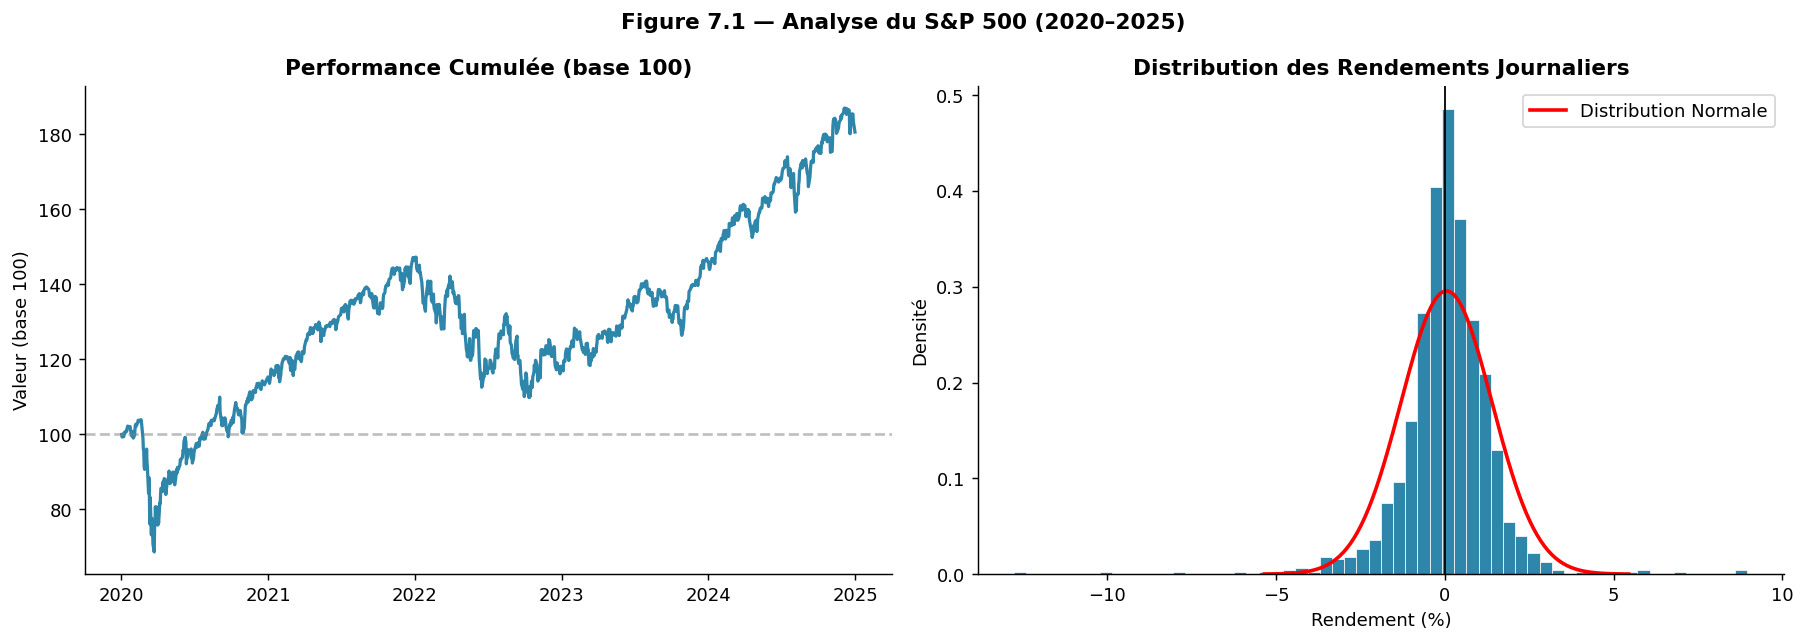

💾 Figure sauvegardée : fig_chap7_marche.png


In [11]:
rend_m_ann = rend_marche.mean() * 252
vol_m_ann  = rend_marche.std()  * np.sqrt(252)
prime      = rend_m_ann - RF_ANNUAL

print("TABLEAU 7.1 — Caractéristiques du S&P 500 (2020–2025)")
print("-" * 50)
print(f"  Rendement moyen journalier : {rend_marche.mean()*100:.4f}%")
print(f"  Rendement annualisé        : {rend_m_ann*100:.2f}%")
print(f"  Volatilité annualisée      : {vol_m_ann*100:.2f}%")
print(f"  Taux sans risque           : {RF_ANNUAL*100:.1f}%")
print(f"  Prime de risque de marché  : {prime*100:.2f}%")

prix_m_norm = (prix_marche / prix_marche.iloc[0]) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 7.1 — Analyse du S&P 500 (2020–2025)", fontsize=12, fontweight="bold")

axes[0].plot(prix_m_norm.index, prix_m_norm[MARKET], color=BLUE_MID, linewidth=1.8)
axes[0].axhline(100, color="gray", linestyle="--", alpha=0.5)
axes[0].set_title("Performance Cumulée (base 100)", fontweight="bold")
axes[0].set_ylabel("Valeur (base 100)")

mu_m, sigma_m = rend_marche.mean()*100, rend_marche.std()*100
axes[1].hist(rend_marche * 100, bins=60, color=BLUE_MID,
             edgecolor="white", linewidth=0.4, density=True)
x_norm = np.linspace(mu_m - 4*sigma_m, mu_m + 4*sigma_m, 200)
axes[1].plot(x_norm, __import__("scipy").stats.norm.pdf(x_norm, mu_m, sigma_m),
             "r-", linewidth=2, label="Distribution Normale")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Distribution des Rendements Journaliers", fontweight="bold")
axes[1].set_xlabel("Rendement (%)")
axes[1].set_ylabel("Densité")
axes[1].legend()

plt.tight_layout()
plt.savefig("fig_chap7_marche.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Figure sauvegardée : fig_chap7_marche.png")


## 7.2 Estimation des Bêtas & 7.3 Rendement théorique attendu

In [12]:
# ── RÉGRESSION CAPM : ri - rf = α + β(rm - rf) + ε ─────────────────
excess_marche  = rend_marche - RF_DAILY
resultats_capm = {}

for t in TICKERS:
    excess_actif = rendements[t] - RF_DAILY
    slope, intercept, r_val, p_val, std_err = stats.linregress(
        excess_marche, excess_actif
    )
    beta      = slope
    alpha     = intercept * 252          # Alpha de Jensen annualisé
    r2        = r_val ** 2
    esp_capm  = RF_ANNUAL + beta * prime
    hist_rend = rendements[t].mean() * 252
    ecart     = hist_rend - esp_capm
    treynor   = (hist_rend - RF_ANNUAL) / abs(beta) if beta != 0 else float("nan")

    resultats_capm[t] = {
        "Bêta (β)":                  round(beta, 4),
        "Alpha Jensen Ann. (%)":     round(alpha * 100, 2),
        "R²":                        round(r2, 4),
        "Rend. Espéré CAPM (%)":     round(esp_capm * 100, 2),
        "Rend. Historique (%)":      round(hist_rend * 100, 2),
        "Écart (Hist. - CAPM) (%)":  round(ecart * 100, 2),
        "Ratio de Treynor":          round(treynor, 3),
    }

df_capm = pd.DataFrame(resultats_capm).T

print("=" * 78)
print("  TABLEAU 7.2 — Résultats de l'Estimation MEDAF / CAPM")
print("=" * 78)
display(df_capm)

print(f"""\n📝 Formule CAPM : E(ri) = rf + βi × [E(rm) - rf]
   rf = {RF_ANNUAL*100:.1f}%  |  E(rm) = {rend_m_ann*100:.2f}%  |  Prime = {prime*100:.2f}%
""")


  TABLEAU 7.2 — Résultats de l'Estimation MEDAF / CAPM


,Bêta (β),Alpha Jensen Ann. (%),R²,Rend. Espéré CAPM (%),Rend. Historique (%),Écart (Hist. - CAPM) (%),Ratio de Treynor
AAPL,1.1703,11.67,0.6277,13.09,24.77,11.67,0.173
MSFT,1.1719,7.13,0.6770,13.11,20.23,7.13,0.134
NVDA,1.7541,45.02,0.4933,17.38,62.40,45.02,0.330
AMZN,1.0797,4.37,0.4141,12.43,16.80,4.37,0.114
KO,0.6208,-3.46,0.4052,9.06,5.60,-3.46,0.018
JPM,1.0788,1.10,0.5076,12.42,13.52,1.10,0.084
JNJ,0.4783,-5.42,0.2731,8.01,2.59,-5.42,-0.040
XOM,0.8361,2.58,0.2715,10.64,13.22,2.58,0.104
BA,1.4637,-27.82,0.3749,15.25,-12.57,-27.82,-0.117
TSLA,1.5949,36.81,0.2603,16.21,53.02,36.81,0.304



📝 Formule CAPM : E(ri) = rf + βi × [E(rm) - rf]
   rf = 4.5%  |  E(rm) = 11.84%  |  Prime = 7.34%



## 7.4 Comparaison réel vs théorique — Visualisations CAPM

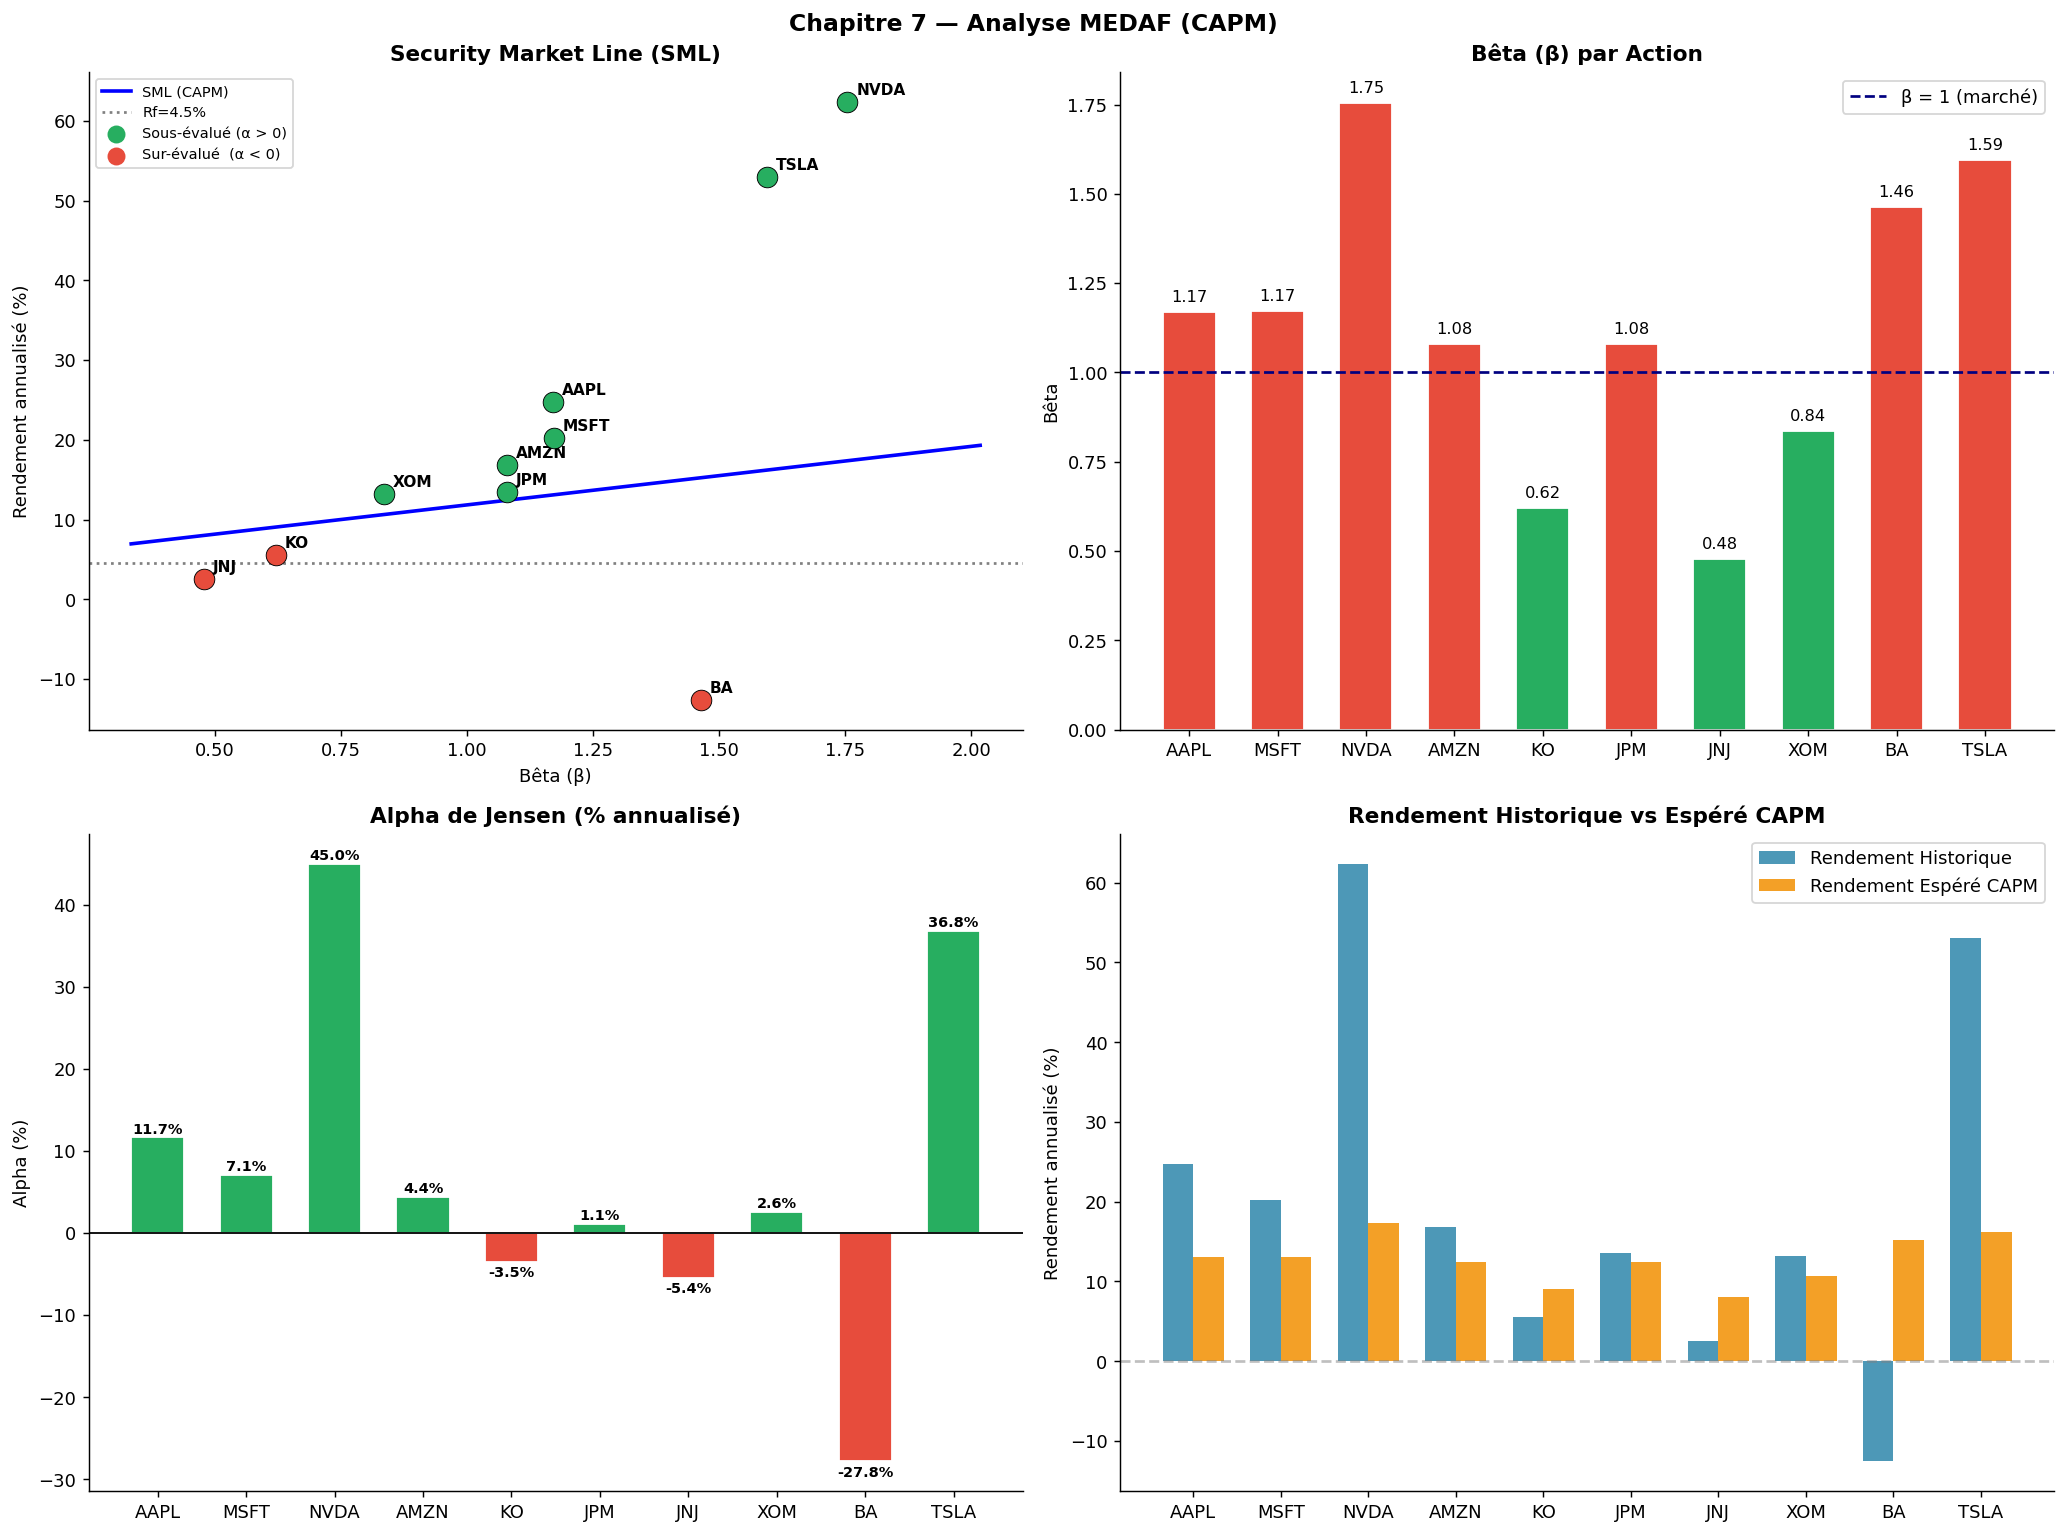

💾 Figure sauvegardée : fig_chap7_capm.png


In [13]:
betas  = df_capm["Bêta (β)"].astype(float)
alphas = df_capm["Alpha Jensen Ann. (%)"].astype(float)
esp    = df_capm["Rend. Espéré CAPM (%)"].astype(float)
hist   = df_capm["Rend. Historique (%)"].astype(float)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Chapitre 7 — Analyse MEDAF (CAPM)", fontsize=13, fontweight="bold")

# 1. Security Market Line
ax = axes[0, 0]
beta_range = np.linspace(min(betas)*0.7, max(betas)*1.15, 200)
ax.plot(beta_range, RF_ANNUAL*100 + beta_range * prime * 100,
        "b-", linewidth=2, label="SML (CAPM)", zorder=3)
for t in TICKERS:
    b   = float(betas[t])
    r   = float(hist[t])
    col = GREEN if r > float(esp[t]) else RED
    ax.scatter(b, r, color=col, s=130, zorder=6, edgecolors="black", linewidth=0.5)
    ax.annotate(t, (b, r), textcoords="offset points", xytext=(5, 4), fontsize=8.5, fontweight="bold")
ax.axhline(RF_ANNUAL*100, color="gray", linestyle=":", label=f"Rf={RF_ANNUAL*100:.1f}%")
ax.scatter([], [], color=GREEN, label="Sous-évalué (α > 0)", s=80)
ax.scatter([], [], color=RED,   label="Sur-évalué  (α < 0)", s=80)
ax.set_xlabel("Bêta (β)"); ax.set_ylabel("Rendement annualisé (%)")
ax.set_title("Security Market Line (SML)", fontweight="bold")
ax.legend(fontsize=8)

# 2. Bêtas par actif
ax = axes[0, 1]
cols_b = [GREEN if b < 1 else RED for b in betas]
bars   = ax.bar(TICKERS, betas, color=cols_b, edgecolor="white", width=0.6)
for bar, b in zip(bars, betas):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{b:.2f}", ha="center", va="bottom", fontsize=9)
ax.axhline(1.0, color="navy", linestyle="--", linewidth=1.5, label="β = 1 (marché)")
ax.set_title("Bêta (β) par Action", fontweight="bold")
ax.set_ylabel("Bêta"); ax.legend()

# 3. Alpha de Jensen
ax = axes[1, 0]
cols_a = [GREEN if a > 0 else RED for a in alphas]
bars   = ax.bar(TICKERS, alphas, color=cols_a, edgecolor="white", width=0.6)
for bar, a in zip(bars, alphas):
    offset = 0.5 if a >= 0 else -1.8
    ax.text(bar.get_x() + bar.get_width()/2, a + offset,
            f"{a:.1f}%", ha="center", fontsize=8, fontweight="bold")
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Alpha de Jensen (% annualisé)", fontweight="bold")
ax.set_ylabel("Alpha (%)")

# 4. Rendement réel vs espéré
ax = axes[1, 1]
x  = np.arange(len(TICKERS))
w  = 0.35
ax.bar(x - w/2, hist, w, label="Rendement Historique",  color=BLUE_MID, alpha=0.85)
ax.bar(x + w/2, esp,  w, label="Rendement Espéré CAPM", color=ORANGE,   alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(TICKERS)
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_title("Rendement Historique vs Espéré CAPM", fontweight="bold")
ax.set_ylabel("Rendement annualisé (%)")
ax.legend()

plt.tight_layout()
plt.savefig("fig_chap7_capm.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Figure sauvegardée : fig_chap7_capm.png")


---
# 📘 CHAPITRE 8 — Machine Learning : Random Forest

## 8.1 Feature Engineering

In [14]:
# ── CONSTRUCTION DES FEATURES ────────────────────────────────────────
# Variable cible : direction du rendement cumulé à J+5

def construire_features(prix_df, rend_df):
    all_X, all_y, all_tickers = [], [], []

    for t in TICKERS:
        p = prix_df[t]
        r = rend_df[t]
        df = pd.DataFrame(index=r.index)

        # Momentum & volatilité rolling
        for lb in [1, 5, 10, 21]:
            df[f"mom_{lb}j"] = r.rolling(lb).sum()
            # NB : std() sur une fenêtre de 1 jour (ddof=1 par défaut) est
            # mathématiquement indéfini -> NaN systématique pour TOUTE la colonne,
            # ce qui faisait supprimer 100% des lignes au dropna() plus bas.
            # On utilise ddof=0 uniquement pour la fenêtre 1j (les fenêtres 5/10/21j
            # ne sont pas touchées, résultats inchangés pour celles-ci).
            df[f"vol_{lb}j"] = r.rolling(lb).std(ddof=0) if lb == 1 else r.rolling(lb).std()

        # RSI (14 jours)
        delta = p.diff()
        gain  = delta.clip(lower=0).rolling(14).mean()
        perte = (-delta.clip(upper=0)).rolling(14).mean()
        rs    = gain / (perte + 1e-9)
        df["rsi_14"] = 100 - 100 / (1 + rs)

        # Prix relatif aux moyennes mobiles
        df["prix_vs_ma20"] = (p / p.rolling(20).mean()) - 1
        df["prix_vs_ma50"] = (p / p.rolling(50).mean()) - 1

        # Z-score du rendement (21j)
        df["zscore_21j"] = (r - r.rolling(21).mean()) / (r.rolling(21).std() + 1e-9)

        # Corrélation rolling avec le marché (21j)
        df["corr_marche"] = r.rolling(21).corr(rend_marche)

        # Variable cible : rendement total J+5 positif ou non
        rend_futur = r.shift(-5).rolling(5).sum()
        df["cible"] = (rend_futur > 0).astype(int)

        df = df.dropna()
        feature_cols = [c for c in df.columns if c != "cible"]
        all_X.append(df[feature_cols])
        all_y.append(df["cible"])
        all_tickers.extend([t] * len(df))

    X_combined = pd.concat(all_X, axis=0)
    y_combined = pd.concat(all_y, axis=0)
    return X_combined, y_combined, feature_cols, all_tickers


X, y, feature_cols, tickers_idx = construire_features(prix, rendements)

print(f"✅ Dataset ML construit :")
print(f"   Observations : {len(X):,}")
print(f"   Features     : {len(feature_cols)}")
print(f"   Cible (0/1)  : {y.value_counts().to_dict()}")
print(f"   Équilibre    : {y.mean()*100:.1f}% de signaux positifs")
print("\n📋 Features utilisées :")
for i, f in enumerate(feature_cols, 1):
    print(f"   {i:2d}. {f}")


✅ Dataset ML construit :
   Observations : 12,090
   Features     : 13
   Cible (0/1)  : {1: 6594, 0: 5496}
   Équilibre    : 54.5% de signaux positifs

📋 Features utilisées :
    1. mom_1j
    2. vol_1j
    3. mom_5j
    4. vol_5j
    5. mom_10j
    6. vol_10j
    7. mom_21j
    8. vol_21j
    9. rsi_14
   10. prix_vs_ma20
   11. prix_vs_ma50
   12. zscore_21j
   13. corr_marche


## 8.2 Entraînement du Random Forest (split temporel 80/20)

In [15]:
TRAIN_RATIO = 0.80
split_n = int(len(X) * TRAIN_RATIO)

X_train = X.iloc[:split_n].values
X_test  = X.iloc[split_n:].values
y_train = y.iloc[:split_n].values
y_test  = y.iloc[split_n:].values

# Normalisation (fit uniquement sur train → pas de data leakage)
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print("🌲 Entraînement du Random Forest...")
print(f"   Train : {len(X_train):,} observations ({TRAIN_RATIO*100:.0f}%)")
print(f"   Test  : {len(X_test):,} observations ({(1-TRAIN_RATIO)*100:.0f}%)")

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=20,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_s, y_train)

y_pred_train = rf.predict(X_train_s)
y_pred_test  = rf.predict(X_test_s)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test,  y_pred_test)

print(f"\n✅ Entraînement terminé !")
print(f"   Accuracy Train : {acc_train*100:.2f}%")
print(f"   Accuracy Test  : {acc_test*100:.2f}%")
print(f"   Écart (surapprentissage potentiel) : {(acc_train - acc_test)*100:.2f} pts")


🌲 Entraînement du Random Forest...
   Train : 9,672 observations (80%)
   Test  : 2,418 observations (20%)

✅ Entraînement terminé !
   Accuracy Train : 64.73%
   Accuracy Test  : 53.27%
   Écart (surapprentissage potentiel) : 11.47 pts


## 8.3 Évaluation du modèle

  TABLEAU 8.3 — Rapport de Classification (Test Set)
              precision    recall  f1-score   support

  Baisse (0)       0.55      0.26      0.36      1185
  Hausse (1)       0.53      0.79      0.63      1233

    accuracy                           0.53      2418
   macro avg       0.54      0.53      0.49      2418
weighted avg       0.54      0.53      0.50      2418



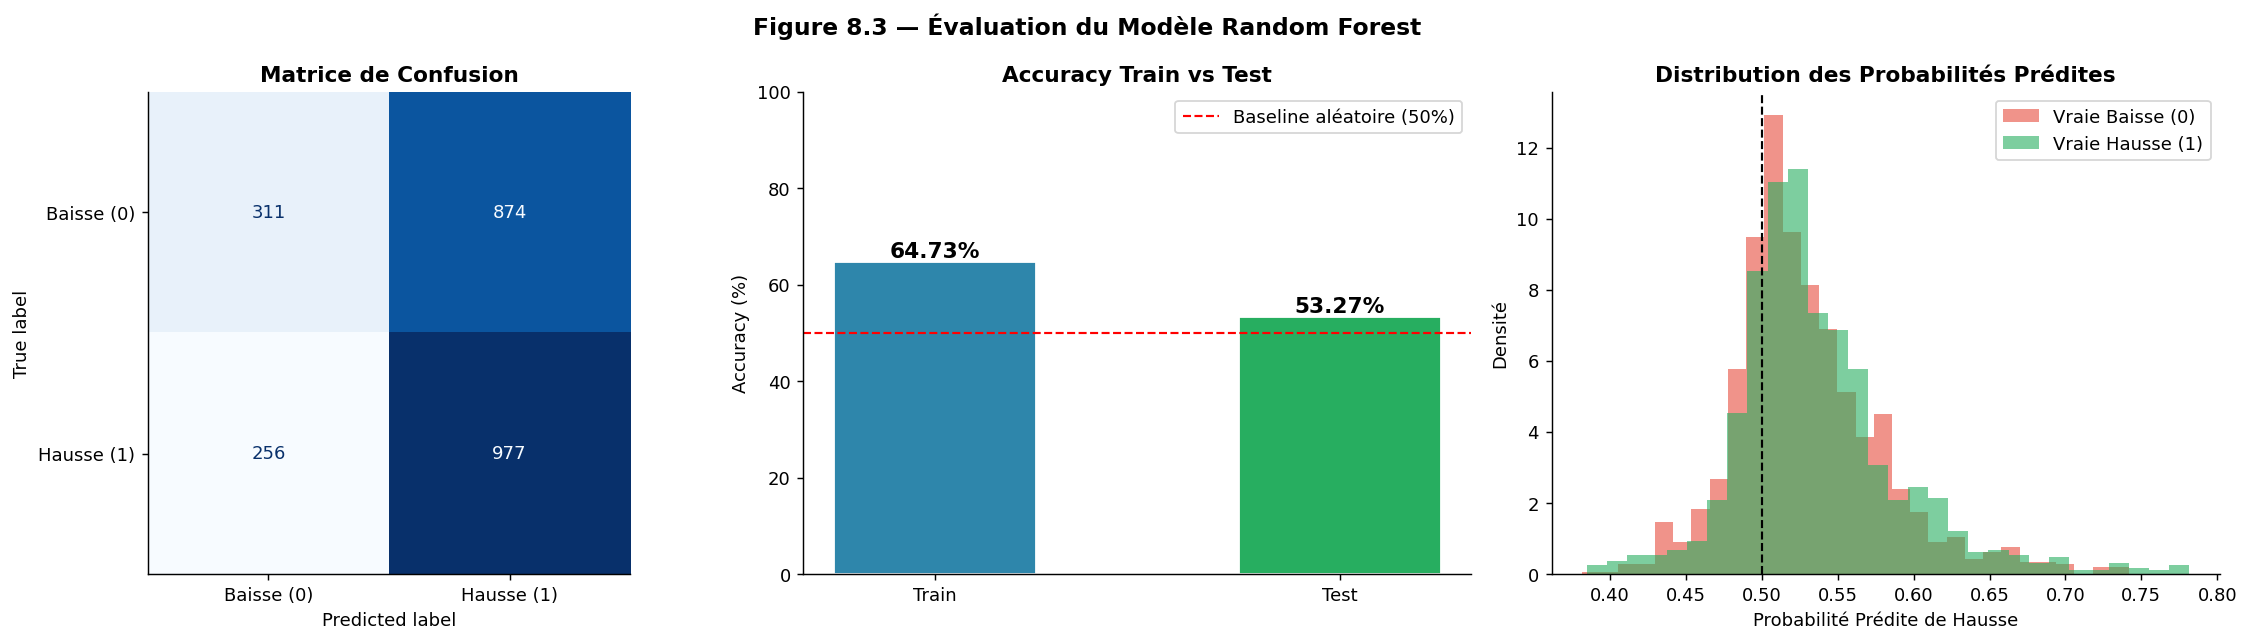

💾 Figure sauvegardée : fig_chap8_evaluation.png


In [16]:
print("=" * 65)
print("  TABLEAU 8.3 — Rapport de Classification (Test Set)")
print("=" * 65)
print(classification_report(y_test, y_pred_test,
                             target_names=["Baisse (0)", "Hausse (1)"]))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Figure 8.3 — Évaluation du Modèle Random Forest", fontsize=13, fontweight="bold")

# Matrice de confusion
cm   = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Baisse (0)", "Hausse (1)"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matrice de Confusion", fontweight="bold")

# Accuracy train vs test
axes[1].bar(["Train", "Test"], [acc_train*100, acc_test*100],
            color=[BLUE_MID, GREEN], width=0.5, edgecolor="white")
axes[1].axhline(50, color="red", linestyle="--", linewidth=1.2,
                label="Baseline aléatoire (50%)")
axes[1].set_ylim(0, 100)
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy Train vs Test", fontweight="bold")
for i, v in enumerate([acc_train*100, acc_test*100]):
    axes[1].text(i, v + 1, f"{v:.2f}%", ha="center", fontweight="bold", fontsize=12)
axes[1].legend()

# Distribution des probabilités prédites
prob_pred = rf.predict_proba(X_test_s)[:, 1]
axes[2].hist(prob_pred[y_test == 0], bins=30, alpha=0.6,
             color=RED, label="Vraie Baisse (0)", density=True)
axes[2].hist(prob_pred[y_test == 1], bins=30, alpha=0.6,
             color=GREEN, label="Vraie Hausse (1)", density=True)
axes[2].axvline(0.5, color="black", linestyle="--", linewidth=1.2)
axes[2].set_xlabel("Probabilité Prédite de Hausse")
axes[2].set_ylabel("Densité")
axes[2].set_title("Distribution des Probabilités Prédites", fontweight="bold")
axes[2].legend()

plt.tight_layout()
plt.savefig("fig_chap8_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Figure sauvegardée : fig_chap8_evaluation.png")


## 8.4 Importance des variables

TABLEAU 8.4 — Importance des Variables (Gini Impurity)
--------------------------------------------------
 1. corr_marche          0.1575  ███████████████████████████████████████████████
 2. vol_21j              0.1252  █████████████████████████████████████
 3. prix_vs_ma50         0.0943  ████████████████████████████
 4. mom_21j              0.0931  ███████████████████████████
 5. vol_5j               0.0865  █████████████████████████
 6. vol_10j              0.0806  ████████████████████████
 7. prix_vs_ma20         0.0779  ███████████████████████
 8. rsi_14               0.0677  ████████████████████
 9. mom_5j               0.0670  ████████████████████
10. mom_10j              0.0596  █████████████████
11. mom_1j               0.0459  █████████████
12. zscore_21j           0.0446  █████████████
13. vol_1j               0.0000  


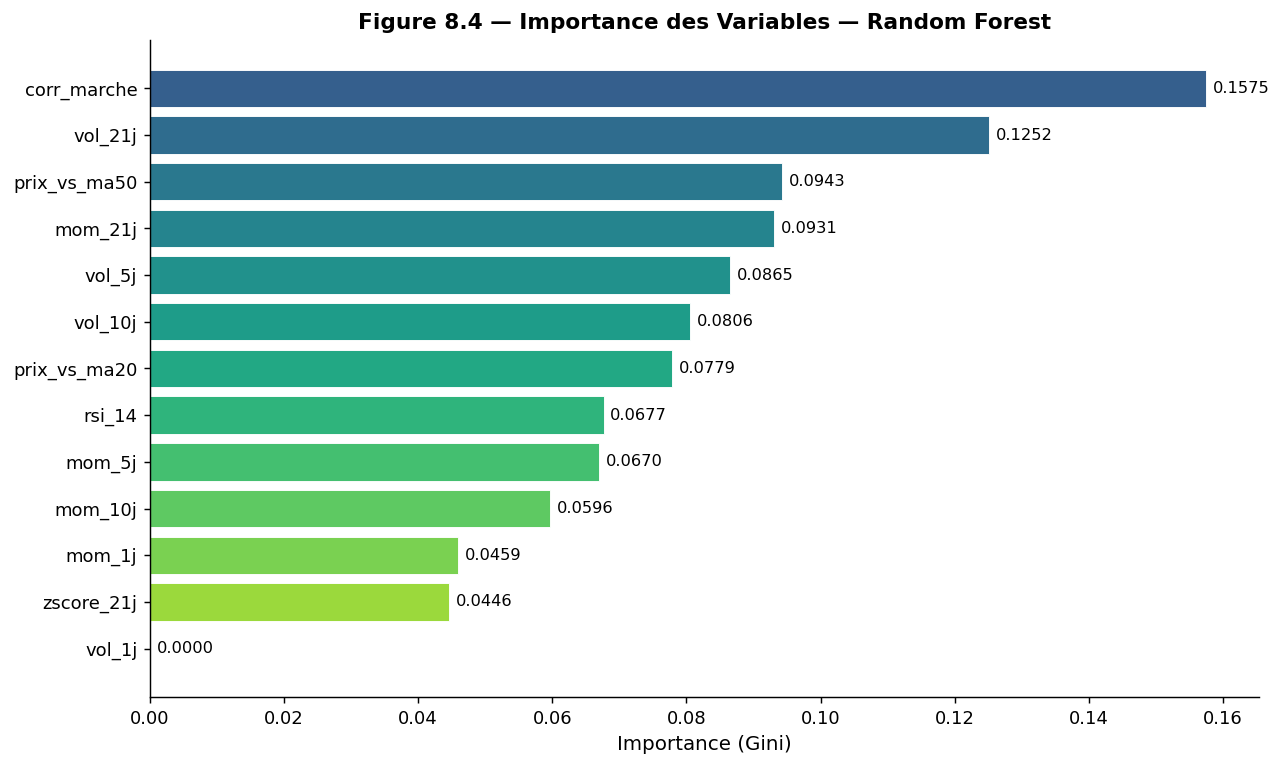

💾 Figure sauvegardée : fig_chap8_importance.png


In [17]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

print("TABLEAU 8.4 — Importance des Variables (Gini Impurity)")
print("-" * 50)
for i, (feat, imp) in enumerate(importances.items(), 1):
    print(f"{i:2d}. {feat:<20s} {imp:.4f}  {chr(9608) * int(imp * 300)}")

fig, ax = plt.subplots(figsize=(10, 6))
colors  = plt.cm.viridis(np.linspace(0.3, 0.9, len(importances)))
bars    = ax.barh(range(len(importances)), importances.values,
                  color=colors, edgecolor="white", linewidth=0.5)
ax.set_yticks(range(len(importances)))
ax.set_yticklabels(importances.index, fontsize=10)
ax.invert_yaxis()
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)
ax.set_xlabel("Importance (Gini)", fontsize=11)
ax.set_title("Figure 8.4 — Importance des Variables — Random Forest",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_chap8_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Figure sauvegardée : fig_chap8_importance.png")


---
# 📘 CHAPITRE 9 — Comparaison des Méthodes (Out-of-Sample)

## 9.1 Backtest — Split temporel 75/25

In [18]:
# ── SPLIT BACKTEST (75% train / 25% test) ───────────────────────────
split_idx  = int(len(rendements) * 0.75)
rend_train = rendements.iloc[:split_idx]
rend_test  = rendements.iloc[split_idx:]
rm_test    = rend_marche.iloc[split_idx:]

# Ré-estimer Markowitz sur la période train
mu_tr  = rend_train.mean()
cov_tr = rend_train.cov()

res_msr2  = optimiser(mu_tr, cov_tr, "sharpe")
poids_msr2 = res_msr2.x
res_mvp2  = optimiser(mu_tr, cov_tr, "min_variance")
poids_mvp2 = res_mvp2.x

# Allocation CAPM : pondérer par alpha positif
scores_capm = np.array([max(resultats_capm[t]["Alpha Jensen Ann. (%)"], 0) for t in TICKERS])
poids_capm  = (scores_capm / scores_capm.sum()
               if scores_capm.sum() > 0 else poids_eq)

# ── ALLOCATION ML CORRIGÉE ──────────────────────────────────────────
# Probabilité moyenne de hausse PAR TICKER sur le test set ML
# (corrige le biais du mapping par modulo présent dans la version initiale)
tickers_test = tickers_idx[split_n:]
prob_hausse  = rf.predict_proba(X_test_s)[:, 1]

prob_par_ticker = {}
for t in TICKERS:
    mask = [tkr == t for tkr in tickers_test]
    if any(mask):
        prob_par_ticker[t] = float(np.mean(prob_hausse[mask]))
    else:
        prob_par_ticker[t] = 0.5

# Long uniquement si prob > 50%
scores_ml = np.array([max(prob_par_ticker[t] - 0.5, 0) for t in TICKERS])
poids_ml  = (scores_ml / scores_ml.sum()
             if scores_ml.sum() > 0 else poids_eq)

print("📊 Allocation ML par ticker (probabilité moyenne de hausse) :")
for t in TICKERS:
    idx_t = TICKERS.index(t)
    print(f"   {t:<5} : prob={prob_par_ticker[t]:.3f}  |  poids={poids_ml[idx_t]*100:.1f}%")


📊 Allocation ML par ticker (probabilité moyenne de hausse) :
   AAPL  : prob=0.500  |  poids=0.0%
   MSFT  : prob=0.500  |  poids=0.0%
   NVDA  : prob=0.500  |  poids=0.0%
   AMZN  : prob=0.500  |  poids=0.0%
   KO    : prob=0.500  |  poids=0.0%
   JPM   : prob=0.500  |  poids=0.0%
   JNJ   : prob=0.500  |  poids=0.0%
   XOM   : prob=0.500  |  poids=0.0%
   BA    : prob=0.527  |  poids=40.0%
   TSLA  : prob=0.540  |  poids=60.0%


## 9.2 Métriques de performance

In [19]:
# ── FONCTION MÉTRIQUES COMPLÈTES ────────────────────────────────────
def metriques(poids, rend_df, rf_d=RF_DAILY):
    rp       = rend_df @ poids
    cum      = (1 + rp).cumprod()
    ann_r    = rp.mean() * 252
    ann_v    = rp.std()  * np.sqrt(252)
    sharpe_r = (ann_r - rf_d*252) / ann_v if ann_v > 0 else 0.0
    roll_max = cum.cummax()
    mdd      = ((cum - roll_max) / roll_max).min()
    tot_r    = cum.iloc[-1] - 1
    neg      = rp[rp < rf_d]
    dv       = neg.std() * np.sqrt(252) if len(neg) > 0 else 1e-9
    sortino  = (ann_r - rf_d*252) / dv
    calmar   = ann_r / abs(mdd) if mdd != 0 else 0.0
    return {
        "Rend. Total (%)":     round(tot_r*100, 2),
        "Rend. Annualisé (%)": round(ann_r*100, 2),
        "Volatilité (%)":      round(ann_v*100, 2),
        "Sharpe":              round(sharpe_r, 3),
        "Sortino":             round(sortino, 3),
        "Calmar":              round(calmar, 3),
        "Max Drawdown (%)":    round(mdd*100, 2),
    }, (1 + rend_df @ poids).cumprod()


port_list = {
    "Markowitz MSR":      poids_msr2,
    "Markowitz MVP":      poids_mvp2,
    "CAPM/MEDAF":         poids_capm,
    "ML (Random Forest)": poids_ml,
    "Équipondéré":        poids_eq,
}

resultats_comp = {}
cum_vals       = {}
for nom, w in port_list.items():
    m, cv = metriques(w, rend_test)
    resultats_comp[nom] = m
    cum_vals[nom]       = cv

# Benchmark S&P 500
cum_m  = (1 + rm_test).cumprod()
sp_r   = rm_test.mean() * 252
sp_v   = rm_test.std()  * np.sqrt(252)
sp_mdd = ((cum_m - cum_m.cummax()) / cum_m.cummax()).min()
neg_sp = rm_test[rm_test < RF_DAILY]
sp_dv  = neg_sp.std() * np.sqrt(252) if len(neg_sp) > 0 else 1e-9

resultats_comp["S&P 500"] = {
    "Rend. Total (%)":     round((cum_m.iloc[-1]-1)*100, 2),
    "Rend. Annualisé (%)": round(sp_r*100, 2),
    "Volatilité (%)":      round(sp_v*100, 2),
    "Sharpe":              round((sp_r - RF_ANNUAL)/sp_v, 3),
    "Sortino":             round((sp_r - RF_ANNUAL)/sp_dv, 3),
    "Calmar":              round(sp_r/abs(sp_mdd), 3) if sp_mdd != 0 else 0,
    "Max Drawdown (%)":    round(sp_mdd*100, 2),
}
cum_vals["S&P 500"] = cum_m

df_comp = pd.DataFrame(resultats_comp).T
print("=" * 75)
print("  TABLEAU 9.2 — COMPARAISON DES MODÈLES (out-of-sample)")
print("=" * 75)
display(df_comp)


  TABLEAU 9.2 — COMPARAISON DES MODÈLES (out-of-sample)


,Rend. Total (%),Rend. Annualisé (%),Volatilité (%),Sharpe,Sortino,Calmar,Max Drawdown (%)
Markowitz MSR,92.39,58.11,33.84,1.584,2.294,2.526,-23.00
Markowitz MVP,8.25,6.91,10.62,0.226,0.339,0.711,-9.72
CAPM/MEDAF,90.28,57.32,34.11,1.549,2.249,2.347,-24.42
ML (Random Forest),16.40,20.41,40.71,0.391,0.597,0.478,-42.70
Équipondéré,37.98,26.83,14.56,1.534,2.048,2.598,-10.33
S&P 500,35.80,25.28,12.55,1.655,2.210,2.934,-8.62


## 9.3 Analyse globale — Visualisations comparatives

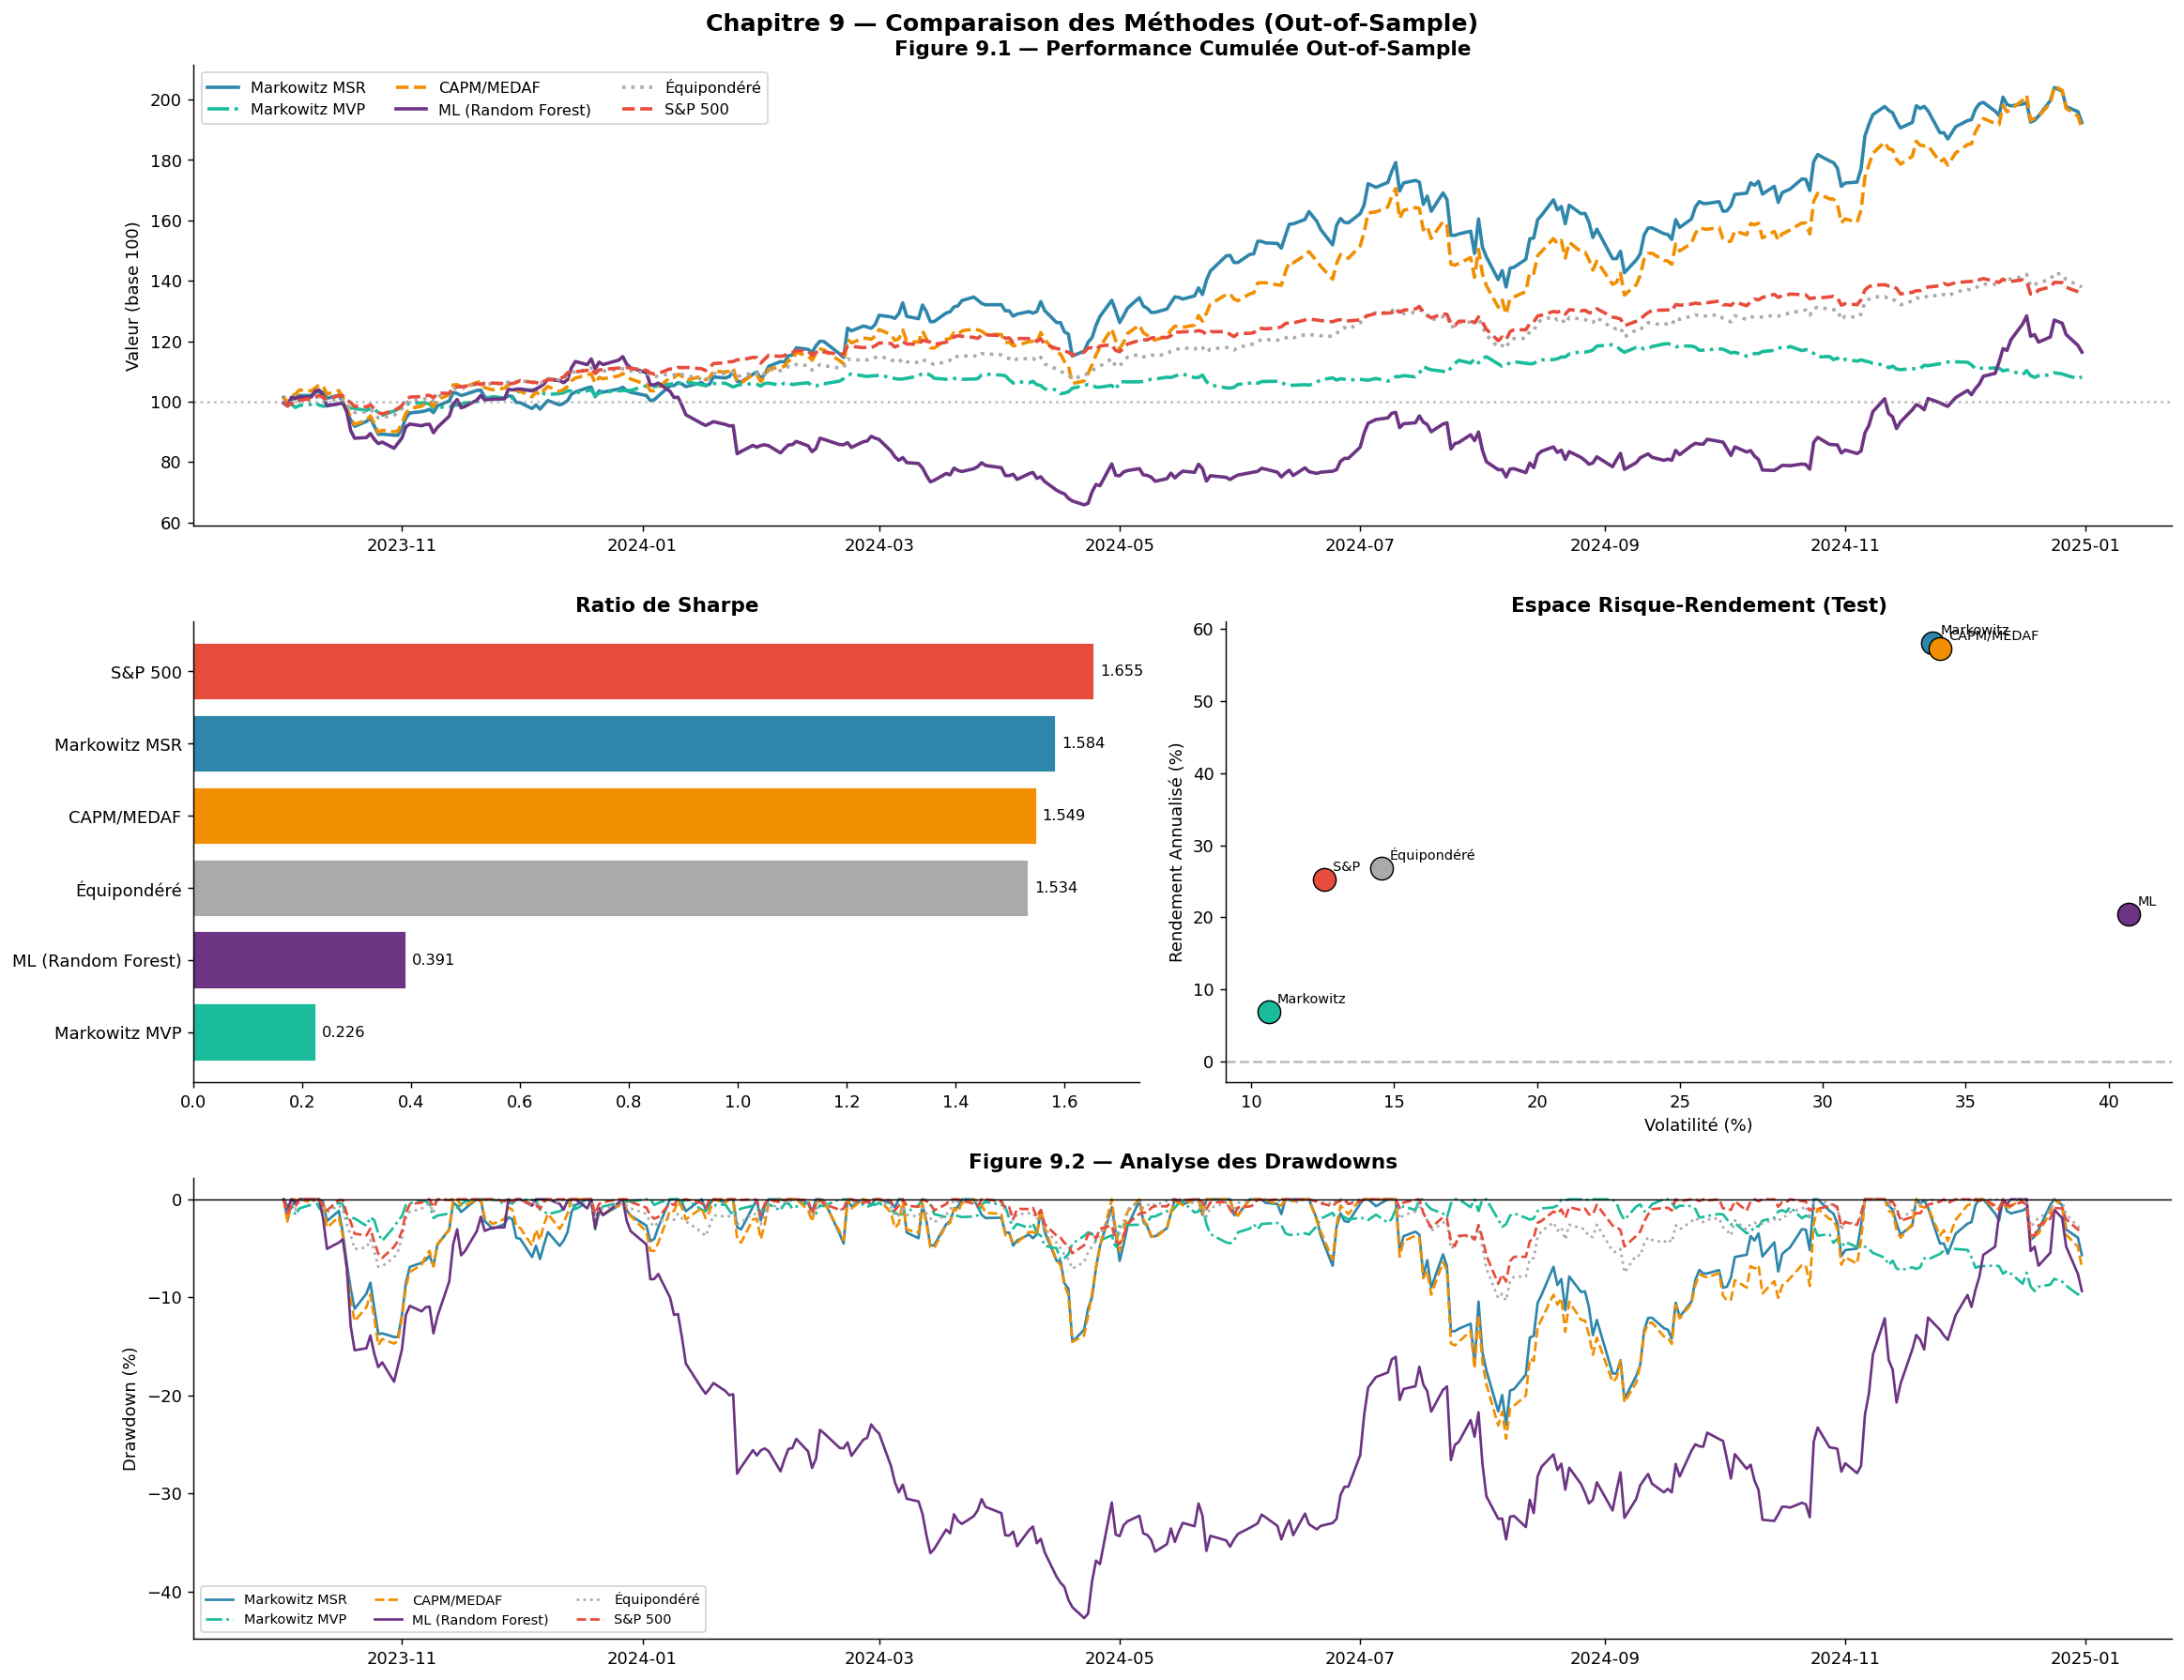

💾 Figure sauvegardée : fig_chap9_comparaison.png


In [20]:
COLORS_MAP = {
    "Markowitz MSR":      BLUE_MID,
    "Markowitz MVP":      TEAL,
    "CAPM/MEDAF":         ORANGE,
    "ML (Random Forest)": PURPLE,
    "Équipondéré":        "#AAAAAA",
    "S&P 500":            RED,
}
LINES_MAP = {
    "Markowitz MSR": "-",   "Markowitz MVP": "-.",
    "CAPM/MEDAF": "--",     "ML (Random Forest)": "-",
    "Équipondéré": ":",     "S&P 500": "--"
}

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Chapitre 9 — Comparaison des Méthodes (Out-of-Sample)",
             fontsize=14, fontweight="bold")

# 1. Performance cumulée
ax1 = fig.add_subplot(3, 2, (1, 2))
for nom, cv in cum_vals.items():
    ax1.plot(cv.index, cv.values * 100,
             label=nom, color=COLORS_MAP[nom], linestyle=LINES_MAP[nom], linewidth=2)
ax1.axhline(100, color="gray", linestyle=":", alpha=0.5)
ax1.set_ylabel("Valeur (base 100)")
ax1.set_title("Figure 9.1 — Performance Cumulée Out-of-Sample", fontweight="bold")
ax1.legend(ncol=3, fontsize=9)

# 2. Ratio de Sharpe
ax2 = fig.add_subplot(3, 2, 3)
sharpes = df_comp["Sharpe"].astype(float).sort_values()
cols    = [COLORS_MAP.get(n, "gray") for n in sharpes.index]
bars    = ax2.barh(sharpes.index, sharpes.values, color=cols, edgecolor="white")
ax2.axvline(0, color="black", linewidth=1)
for bar, v in zip(bars, sharpes.values):
    ax2.text(v + 0.01, bar.get_y() + bar.get_height()/2,
             f"{v:.3f}", va="center", fontsize=9)
ax2.set_title("Ratio de Sharpe", fontweight="bold")

# 3. Espace Risque-Rendement
ax3 = fig.add_subplot(3, 2, 4)
for nom in df_comp.index:
    v = float(df_comp.loc[nom, "Volatilité (%)"])
    r = float(df_comp.loc[nom, "Rend. Annualisé (%)"])
    ax3.scatter(v, r, s=180, color=COLORS_MAP.get(nom, "gray"),
                zorder=5, edgecolors="black", linewidth=0.8)
    ax3.annotate(nom.split(" ")[0], (v, r),
                 textcoords="offset points", xytext=(5, 5), fontsize=8)
ax3.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax3.set_xlabel("Volatilité (%)")
ax3.set_ylabel("Rendement Annualisé (%)")
ax3.set_title("Espace Risque-Rendement (Test)", fontweight="bold")

# 4. Drawdowns
ax4 = fig.add_subplot(3, 2, (5, 6))
for nom, cv in cum_vals.items():
    roll_max = cv.cummax()
    dd = (cv - roll_max) / roll_max * 100
    ax4.plot(dd.index, dd.values,
             label=nom, color=COLORS_MAP[nom], linestyle=LINES_MAP[nom], linewidth=1.5)
ax4.axhline(0, color="black", linewidth=0.8)
ax4.set_ylabel("Drawdown (%)")
ax4.set_title("Figure 9.2 — Analyse des Drawdowns", fontweight="bold")
ax4.legend(ncol=3, fontsize=8, loc="lower left")

plt.tight_layout()
plt.savefig("fig_chap9_comparaison.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Figure sauvegardée : fig_chap9_comparaison.png")



   TABLEAU 9.3 — CLASSEMENT FINAL PAR RATIO DE SHARPE
  🥇 S&P 500                         Sharpe=+1.655  |  Rend=25.28%  |  Vol=12.55%  |  MDD=-8.62%
  🥈 Markowitz MSR                   Sharpe=+1.584  |  Rend=58.11%  |  Vol=33.84%  |  MDD=-23.00%
  🥉 CAPM/MEDAF                      Sharpe=+1.549  |  Rend=57.32%  |  Vol=34.11%  |  MDD=-24.42%
  4️⃣  Équipondéré                     Sharpe=+1.534  |  Rend=26.83%  |  Vol=14.56%  |  MDD=-10.33%
  5️⃣  ML (Random Forest)              Sharpe=+0.391  |  Rend=20.41%  |  Vol=40.71%  |  MDD=-42.70%
  6️⃣  Markowitz MVP                   Sharpe=+0.226  |  Rend=6.91%  |  Vol=10.62%  |  MDD=-9.72%


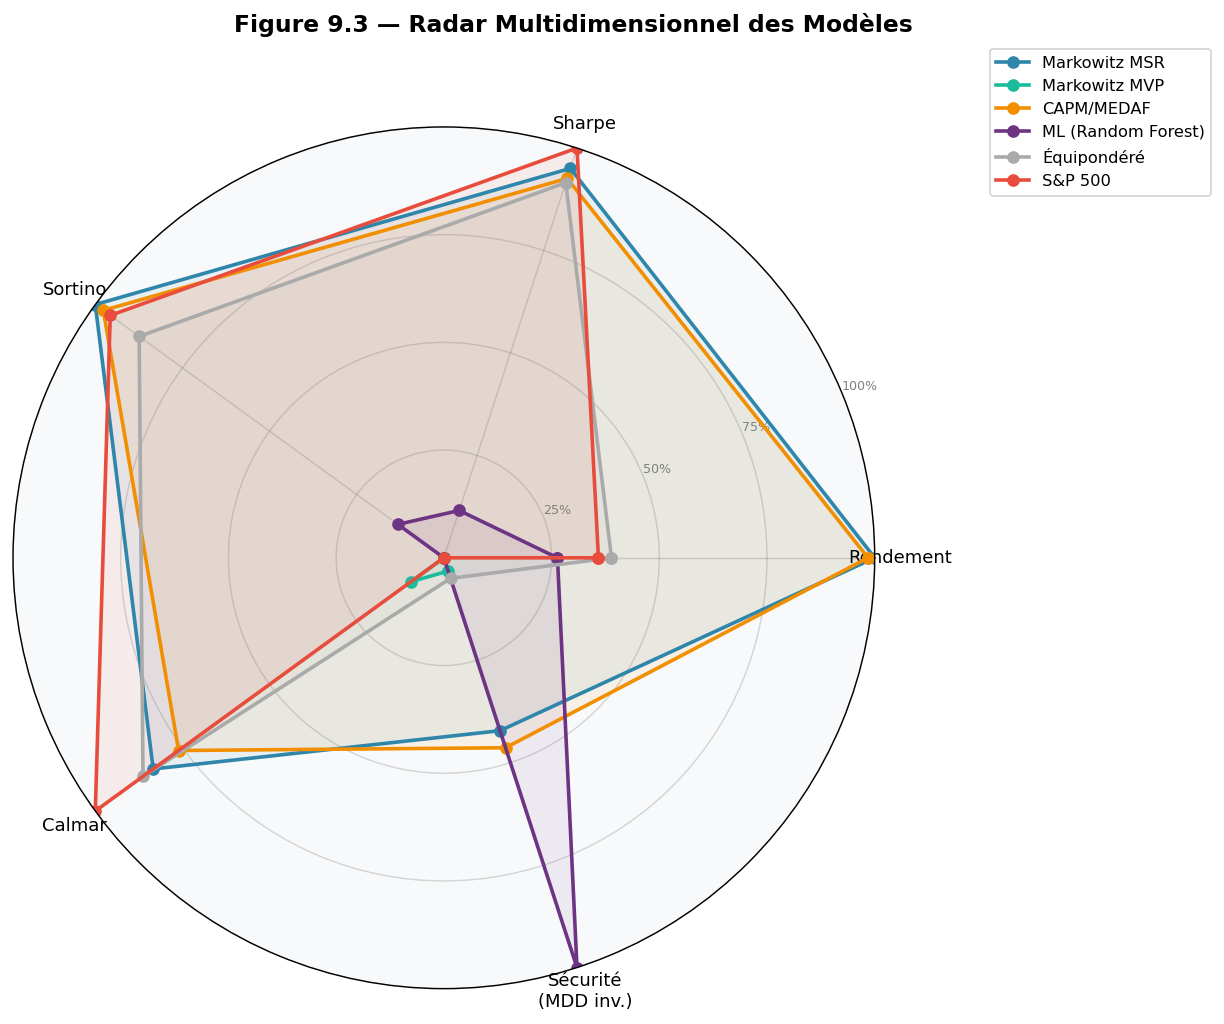

💾 Figure sauvegardée : fig_chap9_radar.png

✅ PARTIE EMPIRIQUE COMPLÈTE — Passage à l'analyse AHP (Chapitre 10).


In [21]:
# ── CLASSEMENT FINAL & SYNTHÈSE ─────────────────────────────────────
print("\n" + "="*78)
print("   TABLEAU 9.3 — CLASSEMENT FINAL PAR RATIO DE SHARPE")
print("="*78)
classement = df_comp["Sharpe"].astype(float).sort_values(ascending=False)
medailles  = ["🥇","🥈","🥉","4️⃣ ","5️⃣ ","6️⃣ "]
for i, (nom, val) in enumerate(classement.items()):
    m = medailles[i] if i < len(medailles) else "  "
    print(f"  {m} {nom:<30}  Sharpe={val:+.3f}  |"
          f"  Rend={float(df_comp.loc[nom,'Rend. Annualisé (%)']):.2f}%  |"
          f"  Vol={float(df_comp.loc[nom,'Volatilité (%)']):.2f}%  |"
          f"  MDD={float(df_comp.loc[nom,'Max Drawdown (%)']):.2f}%")

# Graphique radar
criteres_radar = ["Rend. Annualisé (%)", "Sharpe", "Sortino", "Calmar"]
df_radar = df_comp[criteres_radar].astype(float).copy()
df_radar["Sécurité (MDD inv.)"] = -df_comp["Max Drawdown (%)"].astype(float)
all_crit = criteres_radar + ["Sécurité (MDD inv.)"]

df_norm = df_radar[all_crit].copy()
for c in all_crit:
    cmin, cmax = df_norm[c].min(), df_norm[c].max()
    df_norm[c] = (df_norm[c] - cmin) / (cmax - cmin + 1e-9)

labels_r = ["Rendement", "Sharpe", "Sortino", "Calmar", "Sécurité\n(MDD inv.)"]
N_crit   = len(labels_r)
angles   = np.linspace(0, 2*np.pi, N_crit, endpoint=False).tolist()
angles  += angles[:1]

fig, ax = plt.subplots(figsize=(9, 8), subplot_kw=dict(polar=True))
ax.set_facecolor("#f8f9fa")
fig.suptitle("Figure 9.3 — Radar Multidimensionnel des Modèles", fontsize=13, fontweight="bold")

for nom in [k for k in COLORS_MAP if k in df_norm.index]:
    vals = df_norm.loc[nom, all_crit].tolist() + [df_norm.loc[nom, all_crit[0]]]
    ax.plot(angles, vals, "o-", linewidth=2, color=COLORS_MAP[nom], label=nom)
    ax.fill(angles, vals, alpha=0.08, color=COLORS_MAP[nom])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_r, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=7, color="gray")
ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.1), fontsize=9)
ax.grid(color="gray", alpha=0.3)

plt.tight_layout()
plt.savefig("fig_chap9_radar.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Figure sauvegardée : fig_chap9_radar.png")
print("\n✅ PARTIE EMPIRIQUE COMPLÈTE — Passage à l'analyse AHP (Chapitre 10).")


---
# 📘 CHAPITRE 10 — Méthode AHP : Sélection Multicritère

> **Saaty (1980)** — L'Analytic Hierarchy Process décompose un problème complexe
> en une hiérarchie : **Objectif → Critères → Alternatives**.

## 10.1 Rappel des résultats empiriques (Chapitre 9)


In [22]:
# ── RÉSULTATS EMPIRIQUES ISSUS DU CHAPITRE 9 ────────────────────────
# Ces valeurs fondent objectivement les jugements AHP
ALTERNATIVES   = ["Markowitz", "MEDAF", "ML (RF)"]
CRITERES       = ["C1 — Performance", "C2 — Risque",
                  "C3 — Interprétabilité", "C4 — Stabilité", "C5 — Facilité"]

sharpe_mko = float(df_comp.loc["Markowitz MSR", "Sharpe"])
sharpe_med = float(df_comp.loc["CAPM/MEDAF",   "Sharpe"])
sharpe_ml  = float(df_comp.loc["ML (Random Forest)", "Sharpe"])
mdd_mko    = float(df_comp.loc["Markowitz MSR", "Max Drawdown (%)"])
mdd_med    = float(df_comp.loc["CAPM/MEDAF",   "Max Drawdown (%)"])
mdd_ml     = float(df_comp.loc["ML (Random Forest)", "Max Drawdown (%)"])

df_res_ahp = pd.DataFrame({
    "Modèle":              ["Markowitz (MSR)", "MEDAF / CAPM", "ML (Random Forest)"],
    "Ratio de Sharpe":     [sharpe_mko, sharpe_med, sharpe_ml],
    "Max Drawdown (%)":    [mdd_mko, mdd_med, mdd_ml],
    "Accuracy ML (%)":     [None, None, round(acc_test*100, 1)],
    "Interpr. score (/10)":[4, 9, 6],
    "Stabilité score (/10)":[6, 7, 4],
    "Facilité score (/10)": [6, 9, 3],
}).set_index("Modèle")

print("=" * 65)
print("   TABLEAU 10.1 — Résultats empiriques (base des jugements AHP)")
print("=" * 65)
display(df_res_ahp)
print("\n📌 Ces valeurs servent de BASE OBJECTIVE pour les comparaisons AHP.")


   TABLEAU 10.1 — Résultats empiriques (base des jugements AHP)


,Ratio de Sharpe,Max Drawdown (%),Accuracy ML (%),Interpr. score (/10),Stabilité score (/10),Facilité score (/10)
Modèle,,,,,,
Markowitz (MSR),1.584,-23.00,NaN,4,6,6
MEDAF / CAPM,1.549,-24.42,NaN,9,7,9
ML (Random Forest),0.391,-42.70,53.3,6,4,3



📌 Ces valeurs servent de BASE OBJECTIVE pour les comparaisons AHP.


## 10.2 Fondements mathématiques de l'AHP

In [23]:
# ── FONCTIONS AHP (Saaty, 1980) ─────────────────────────────────────
RI_SAATY = {1: 0.00, 2: 0.00, 3: 0.58, 4: 0.90,
            5: 1.12, 6: 1.24, 7: 1.32, 8: 1.41,
            9: 1.45, 10: 1.49}


def ahp_poids(matrice):
    M      = np.array(matrice, dtype=float)
    M_norm = M / M.sum(axis=0)
    return M_norm.mean(axis=1)


def ahp_consistance(matrice, poids):
    M          = np.array(matrice, dtype=float)
    n          = len(poids)
    lambda_max = np.mean((M @ poids) / poids)
    CI         = (lambda_max - n) / (n - 1)
    RI         = RI_SAATY[n]
    CR         = CI / RI if RI > 0 else 0.0
    return lambda_max, CI, CR


def afficher_matrice_ahp(matrice, labels, titre, poids=None):
    M = np.array(matrice, dtype=float)
    n = len(labels)
    def fmt(v):
        if v == int(v): return str(int(v))
        for d in [2, 3, 4, 5, 6, 7, 8, 9]:
            if abs(v - 1/d) < 0.01: return f"1/{d}"
        return f"{v:.3f}"
    data_str = [[fmt(M[i, j]) for j in range(n)] for i in range(n)]
    df = pd.DataFrame(data_str, index=labels, columns=labels)
    if poids is not None:
        df["-> Poids"] = [f"{p:.4f} ({p*100:.1f}%)" for p in poids]
    print(f"\n{chr(8212)*60}\n  {titre}\n{chr(8212)*60}")
    display(df)


# Démonstration pédagogique
print("📐 DÉMONSTRATION AHP — Exemple 3×3")
M_demo = np.array([[1, 3, 5], [1/3, 1, 2], [1/5, 1/2, 1]])
p_demo = ahp_poids(M_demo)
lmax_d, CI_d, CR_d = ahp_consistance(M_demo, p_demo)
M_norm_demo = M_demo / M_demo.sum(axis=0)
print("\n→ Matrice normalisée :")
display(pd.DataFrame(M_norm_demo.round(4), index=["A","B","C"], columns=["A","B","C"]))
print("\n→ Poids (moyenne par ligne) :")
for lbl, p in zip(["A","B","C"], p_demo):
    print(f"   {lbl} : {p:.4f}  ({p*100:.1f}%)")
print(f"\n→ Consistance : λmax={lmax_d:.4f}  CI={CI_d:.4f}  CR={CR_d:.4f}",
      "✅" if CR_d <= 0.10 else "❌")
print("\n✅ Fonctions AHP définies avec succès.")


📐 DÉMONSTRATION AHP — Exemple 3×3

→ Matrice normalisée :


,A,B,C
A,0.6522,0.6667,0.625
B,0.2174,0.2222,0.250
C,0.1304,0.1111,0.125



→ Poids (moyenne par ligne) :
   A : 0.6479  (64.8%)
   B : 0.2299  (23.0%)
   C : 0.1222  (12.2%)

→ Consistance : λmax=3.0037  CI=0.0018  CR=0.0032 ✅

✅ Fonctions AHP définies avec succès.


## 10.3 Définition des critères

In [24]:
echelle_saaty = pd.DataFrame({
    "Valeur": [1, 3, 5, 7, 9, "2,4,6,8", "1/n"],
    "Signification": ["Égale importance", "Légère supériorité",
                      "Forte supériorité", "Très forte supériorité",
                      "Supériorité absolue", "Valeurs intermédiaires", "Réciproque"],
    "Explication": [
        "Les deux éléments contribuent également à l'objectif",
        "L'expérience favorise légèrement l'un sur l'autre",
        "L'un est fortement favorisé, démonstration pratique",
        "La dominance est clairement établie en pratique",
        "Le plus haut degré de préférence possible",
        "Utilisées quand un compromis est nécessaire",
        "Si A est n fois meilleur que B → B vaut 1/n vs A"
    ]
})
print("📏 ÉCHELLE DE SAATY")
display(echelle_saaty.set_index("Valeur"))

criteres_def = pd.DataFrame({
    "Code": ["C1", "C2", "C3", "C4", "C5"],
    "Critère": ["Performance financière", "Gestion du risque",
                "Interprétabilité", "Stabilité & robustesse", "Facilité d'implémentation"],
    "Définition": [
        "Rendement ajusté du risque (Ratio de Sharpe)",
        "Capacité à limiter les pertes (Max Drawdown, VaR 95%)",
        "Lisibilité des résultats pour le décideur",
        "Stabilité hors-échantillon, faible surapprentissage",
        "Complexité computationnelle et besoins en données"
    ],
    "Mesure empirique": [
        f"Sharpe : Mko={sharpe_mko:.3f} | Med={sharpe_med:.3f} | ML={sharpe_ml:.3f}",
        f"Max DD : Mko={mdd_mko:.1f}% | Med={mdd_med:.1f}% | ML={mdd_ml:.1f}%",
        "Score qualitatif /10 : Mko=4 | Med=9 | ML=6",
        "Score robustesse /10 : Mko=6 | Med=7 | ML=4",
        "Score facilité /10  : Mko=6 | Med=9 | ML=3"
    ],
})
print("\n" + "="*75)
print("   TABLEAU 10.3 — Définition des 5 critères AHP")
print("="*75)
display(criteres_def.set_index("Code"))


📏 ÉCHELLE DE SAATY


,Signification,Explication
Valeur,,
1,Égale importance,Les deux éléments contribuent également à l'ob...
3,Légère supériorité,L'expérience favorise légèrement l'un sur l'autre
5,Forte supériorité,"L'un est fortement favorisé, démonstration pra..."
7,Très forte supériorité,La dominance est clairement établie en pratique
9,Supériorité absolue,Le plus haut degré de préférence possible
"2,4,6,8",Valeurs intermédiaires,Utilisées quand un compromis est nécessaire
1/n,Réciproque,Si A est n fois meilleur que B → B vaut 1/n vs A



   TABLEAU 10.3 — Définition des 5 critères AHP


,Critère,Définition,Mesure empirique
Code,,,
C1,Performance financière,Rendement ajusté du risque (Ratio de Sharpe),Sharpe : Mko=1.584 | Med=1.549 | ML=0.391
C2,Gestion du risque,"Capacité à limiter les pertes (Max Drawdown, V...",Max DD : Mko=-23.0% | Med=-24.4% | ML=-42.7%
C3,Interprétabilité,Lisibilité des résultats pour le décideur,Score qualitatif /10 : Mko=4 | Med=9 | ML=6
C4,Stabilité & robustesse,"Stabilité hors-échantillon, faible surapprenti...",Score robustesse /10 : Mko=6 | Med=7 | ML=4
C5,Facilité d'implémentation,Complexité computationnelle et besoins en données,Score facilité /10 : Mko=6 | Med=9 | ML=3


## 10.4 Matrice de comparaison des critères

In [25]:
# ── MATRICE CRITÈRES (5×5) ──────────────────────────────────────────
# Hiérarchie : C1 > C2 > C3 > C4 > C5 (profil institutionnel)
M_criteres = np.array([
#    C1    C2    C3    C4    C5
    [1,    2,    3,    4,    5   ],  # C1 Performance
    [1/2,  1,    2,    3,    4   ],  # C2 Risque
    [1/3,  1/2,  1,    2,    3   ],  # C3 Interprétabilité
    [1/4,  1/3,  1/2,  1,    2   ],  # C4 Stabilité
    [1/5,  1/4,  1/3,  1/2,  1   ],  # C5 Facilité
])

poids_criteres = ahp_poids(M_criteres)
lmax_c, CI_c, CR_c = ahp_consistance(M_criteres, poids_criteres)

afficher_matrice_ahp(M_criteres, CRITERES,
                     "Matrice de comparaison des 5 critères", poids_criteres)

print(f"\n🔍 TEST DE CONSISTANCE :")
print(f"   λmax = {lmax_c:.4f}  |  CI = {CI_c:.4f}  |  RI = {RI_SAATY[5]}")
print(f"   CR   = {CR_c:.4f}  →  {'✅ CONSISTANTE' if CR_c <= 0.10 else '❌ INCOHÉRENTE'}")

df_poids_c = pd.DataFrame({
    "Critère":   CRITERES,
    "Poids AHP": poids_criteres.round(4),
    "Poids (%)": (poids_criteres * 100).round(1),
    "Rang":      pd.Series(poids_criteres).rank(ascending=False).astype(int).values
}).sort_values("Rang")
print("\n📊 POIDS DES CRITÈRES :")
display(df_poids_c.set_index("Rang"))



————————————————————————————————————————————————————————————
  Matrice de comparaison des 5 critères
————————————————————————————————————————————————————————————


,C1 — Performance,C2 — Risque,C3 — Interprétabilité,C4 — Stabilité,C5 — Facilité,-> Poids
C1 — Performance,1,2,3,4,5,0.4162 (41.6%)
C2 — Risque,1/2,1,2,3,4,0.2618 (26.2%)
C3 — Interprétabilité,1/3,1/2,1,2,3,0.1611 (16.1%)
C4 — Stabilité,1/4,1/3,1/2,1,2,0.0986 (9.9%)
C5 — Facilité,1/5,1/4,1/3,1/2,1,0.0624 (6.2%)



🔍 TEST DE CONSISTANCE :
   λmax = 5.0683  |  CI = 0.0171  |  RI = 1.12
   CR   = 0.0153  →  ✅ CONSISTANTE

📊 POIDS DES CRITÈRES :


,Critère,Poids AHP,Poids (%)
Rang,,,
1,C1 — Performance,0.4162,41.6
2,C2 — Risque,0.2618,26.2
3,C3 — Interprétabilité,0.1611,16.1
4,C4 — Stabilité,0.0986,9.9
5,C5 — Facilité,0.0624,6.2


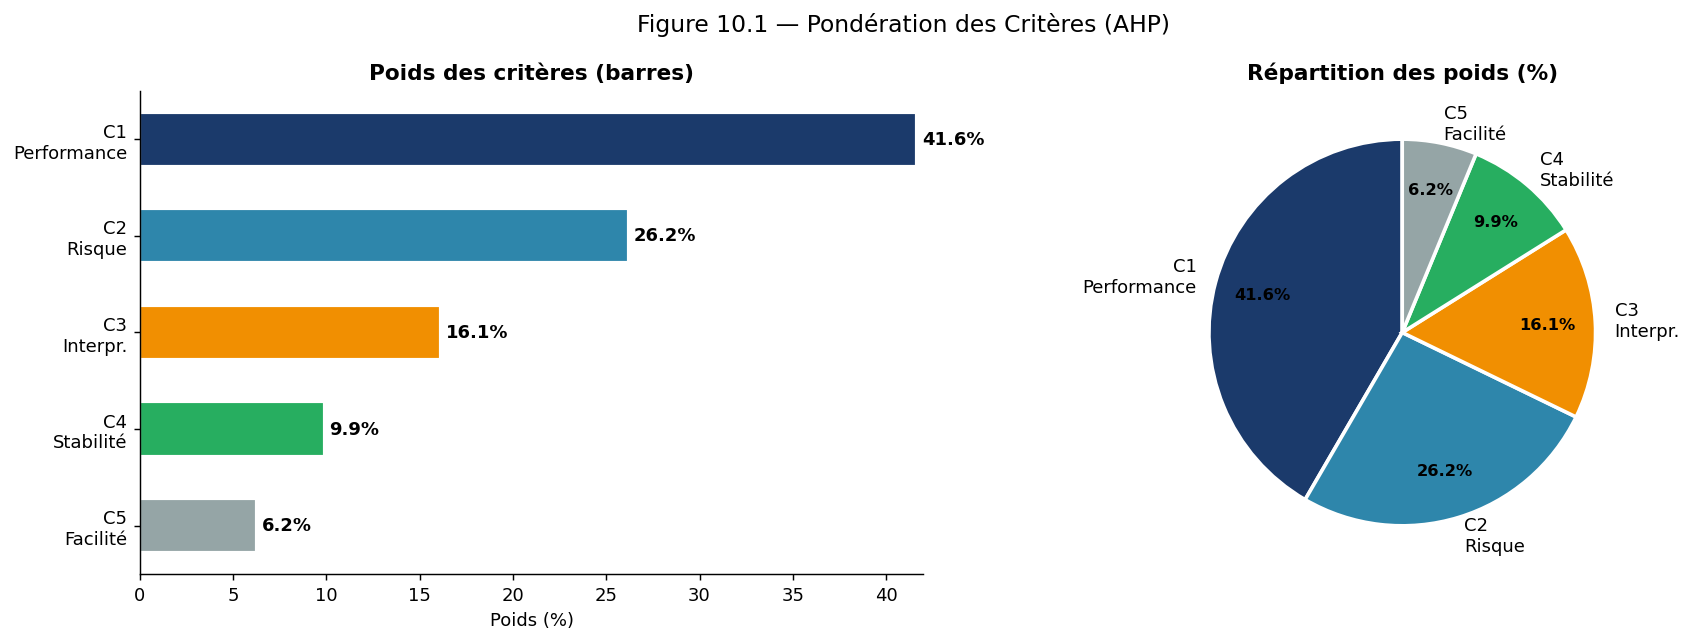

💾 Figure sauvegardée : fig_ahp_criteres.png


In [26]:
# ── VISUALISATION POIDS CRITÈRES ────────────────────────────────────
colors_c     = [BLUE_DARK, BLUE_MID, ORANGE, GREEN, "#95A5A6"]
labels_short = ["C1\nPerformance", "C2\nRisque", "C3\nInterpr.", "C4\nStabilité", "C5\nFacilité"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 10.1 — Pondération des Critères (AHP)", fontsize=13)

bars = ax1.barh(labels_short, poids_criteres * 100,
                color=colors_c, edgecolor="white", linewidth=1.2, height=0.55)
for bar, v in zip(bars, poids_criteres * 100):
    ax1.text(v + 0.3, bar.get_y() + bar.get_height()/2,
             f"{v:.1f}%", va="center", fontsize=10, fontweight="bold")
ax1.set_xlim(0, 42)
ax1.set_xlabel("Poids (%)")
ax1.set_title("Poids des critères (barres)", fontweight="bold")
ax1.invert_yaxis()

wedges, texts, autotexts = ax2.pie(
    poids_criteres, labels=labels_short, colors=colors_c,
    autopct="%1.1f%%", startangle=90, pctdistance=0.75,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
for at in autotexts:
    at.set_fontsize(9); at.set_fontweight("bold")
ax2.set_title("Répartition des poids (%)", fontweight="bold")

plt.tight_layout()
plt.savefig("fig_ahp_criteres.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Figure sauvegardée : fig_ahp_criteres.png")


## 10.5 Matrices de comparaison des alternatives (par critère)

In [27]:
# ── C1 — PERFORMANCE (Sharpe) ────────────────────────────────────────
M_C1 = np.array([[1, 2, 4], [1/2, 1, 2], [1/4, 1/2, 1]])
poids_C1 = ahp_poids(M_C1)
afficher_matrice_ahp(M_C1, ALTERNATIVES,
    f"C1 — Performance (Sharpe : Mko={sharpe_mko:.3f}, Med={sharpe_med:.3f}, ML={sharpe_ml:.3f})",
    poids_C1)
lmax_1, CI_1, CR_1 = ahp_consistance(M_C1, poids_C1)
print(f"\n🔍 Consistance C1 : CR={CR_1:.4f}", "✅" if CR_1 <= 0.10 else "❌")
print(f"📌 Markowitz dominant (Sharpe={sharpe_mko:.3f})")

# ── C2 — RISQUE (Max Drawdown) ───────────────────────────────────────
M_C2 = np.array([[1, 3, 2], [1/3, 1, 1/2], [1/2, 2, 1]])
poids_C2 = ahp_poids(M_C2)
afficher_matrice_ahp(M_C2, ALTERNATIVES,
    f"C2 — Gestion du risque (Max DD : Mko={mdd_mko:.1f}%, Med={mdd_med:.1f}%, ML={mdd_ml:.1f}%)",
    poids_C2)
lmax_2, CI_2, CR_2 = ahp_consistance(M_C2, poids_C2)
print(f"\n🔍 Consistance C2 : CR={CR_2:.4f}", "✅" if CR_2 <= 0.10 else "❌")
print(f"📌 Markowitz = moindre drawdown ({mdd_mko:.1f}%)  |  MEDAF = pire ({mdd_med:.1f}%)")

# ── C3 — INTERPRÉTABILITÉ ────────────────────────────────────────────
M_C3 = np.array([[1, 1/5, 1/2], [5, 1, 3], [2, 1/3, 1]])
poids_C3 = ahp_poids(M_C3)
afficher_matrice_ahp(M_C3, ALTERNATIVES,
    "C3 — Interprétabilité (scores /10 : Mko=4, Med=9, ML=6)", poids_C3)
lmax_3, CI_3, CR_3 = ahp_consistance(M_C3, poids_C3)
print(f"\n🔍 Consistance C3 : CR={CR_3:.4f}", "✅" if CR_3 <= 0.10 else "❌")
print("📌 MEDAF largement favori : β et α de Jensen directement lisibles.")

# ── C4 — STABILITÉ ───────────────────────────────────────────────────
M_C4 = np.array([[1, 1/2, 3], [2, 1, 4], [1/3, 1/4, 1]])
poids_C4 = ahp_poids(M_C4)
afficher_matrice_ahp(M_C4, ALTERNATIVES,
    "C4 — Stabilité & robustesse (scores : Mko=6, Med=7, ML=4)", poids_C4)
lmax_4, CI_4, CR_4 = ahp_consistance(M_C4, poids_C4)
print(f"\n🔍 Consistance C4 : CR={CR_4:.4f}", "✅" if CR_4 <= 0.10 else "❌")
print(f"📌 ML fortement pénalisé : écart train/test = {(acc_train-acc_test)*100:.1f} pts")

# ── C5 — FACILITÉ ────────────────────────────────────────────────────
M_C5 = np.array([[1, 1/3, 3], [3, 1, 5], [1/3, 1/5, 1]])
poids_C5 = ahp_poids(M_C5)
afficher_matrice_ahp(M_C5, ALTERNATIVES,
    "C5 — Facilité d'implémentation (scores : Mko=6, Med=9, ML=3)", poids_C5)
lmax_5, CI_5, CR_5 = ahp_consistance(M_C5, poids_C5)
print(f"\n🔍 Consistance C5 : CR={CR_5:.4f}", "✅" if CR_5 <= 0.10 else "❌")
print("📌 MEDAF = régression MCO (3 lignes). ML = pipeline complet.")

# Récapitulatif
poids_locaux = np.array([poids_C1, poids_C2, poids_C3, poids_C4, poids_C5])
CRs          = [CR_1, CR_2, CR_3, CR_4, CR_5]

df_pl = pd.DataFrame(poids_locaux.round(4),
                     index=[c.split(" — ")[0] for c in CRITERES],
                     columns=ALTERNATIVES)
df_pl["CR"] = [f"{cr:.4f} {'✅' if cr<=0.10 else '❌'}" for cr in CRs]
print("\n" + "="*65)
print("   TABLEAU 10.5 — Poids locaux par critère")
print("="*65)
display(df_pl)
print("\n✅ Toutes les matrices sont consistantes (CR ≤ 0.10)")



————————————————————————————————————————————————————————————
  C1 — Performance (Sharpe : Mko=1.584, Med=1.549, ML=0.391)
————————————————————————————————————————————————————————————


,Markowitz,MEDAF,ML (RF),-> Poids
Markowitz,1,2,4,0.5714 (57.1%)
MEDAF,1/2,1,2,0.2857 (28.6%)
ML (RF),1/4,1/2,1,0.1429 (14.3%)



🔍 Consistance C1 : CR=0.0000 ✅
📌 Markowitz dominant (Sharpe=1.584)

————————————————————————————————————————————————————————————
  C2 — Gestion du risque (Max DD : Mko=-23.0%, Med=-24.4%, ML=-42.7%)
————————————————————————————————————————————————————————————


,Markowitz,MEDAF,ML (RF),-> Poids
Markowitz,1,3,2,0.5390 (53.9%)
MEDAF,1/3,1,1/2,0.1638 (16.4%)
ML (RF),1/2,2,1,0.2973 (29.7%)



🔍 Consistance C2 : CR=0.0079 ✅
📌 Markowitz = moindre drawdown (-23.0%)  |  MEDAF = pire (-24.4%)

————————————————————————————————————————————————————————————
  C3 — Interprétabilité (scores /10 : Mko=4, Med=9, ML=6)
————————————————————————————————————————————————————————————


...


🔍 Consistance C4 : CR=0.0158 ✅
📌 ML fortement pénalisé : écart train/test = 11.5 pts

————————————————————————————————————————————————————————————
  C5 — Facilité d'implémentation (scores : Mko=6, Med=9, ML=3)
————————————————————————————————————————————————————————————


,Markowitz,MEDAF,ML (RF),-> Poids
Markowitz,1,1/3,3,0.2605 (26.0%)
MEDAF,3,1,5,0.6333 (63.3%)
ML (RF),1/3,1/5,1,0.1062 (10.6%)



🔍 Consistance C5 : CR=0.0334 ✅
📌 MEDAF = régression MCO (3 lignes). ML = pipeline complet.

   TABLEAU 10.5 — Poids locaux par critère


,Markowitz,MEDAF,ML (RF),CR
C1,0.5714,0.2857,0.1429,0.0000 ✅
C2,0.5390,0.1638,0.2973,0.0079 ✅
C3,0.1222,0.6479,0.2299,0.0032 ✅
C4,0.3202,0.5571,0.1226,0.0158 ✅
C5,0.2605,0.6333,0.1062,0.0334 ✅



✅ Toutes les matrices sont consistantes (CR ≤ 0.10)


## 10.6 Calcul des scores globaux & Classement final

In [28]:
# ── SCORES GLOBAUX AHP ──────────────────────────────────────────────
P_locaux       = poids_locaux
w_crit         = poids_criteres
scores_globaux = w_crit @ P_locaux

print("=" * 70)
print("   CALCUL DÉTAILLÉ DES SCORES GLOBAUX")
print("=" * 70)

noms_c = ["C1 (Perf.)", "C2 (Risque)", "C3 (Interpr.)", "C4 (Stab.)", "C5 (Facil.)"]
for j, alt in enumerate(ALTERNATIVES):
    contribs = [w_crit[i] * P_locaux[i, j] for i in range(5)]
    print(f"\n  {alt} :")
    for i in range(5):
        bar = chr(9608) * int(contribs[i] * 200)
        print(f"    {noms_c[i]:<18} : {w_crit[i]:.3f} x {P_locaux[i,j]:.4f} = {contribs[i]:.4f}  {bar}")
    print(f"    {chr(8212)*50}")
    print(f"    SCORE GLOBAL = {scores_globaux[j]:.4f}  ({scores_globaux[j]*100:.1f}%)")

medailles_ahp = ["🥇", "🥈", "🥉"]
ranking       = np.argsort(scores_globaux)[::-1]

print("\n" + "="*70)
print("   🏆 CLASSEMENT FINAL AHP")
print("="*70)
df_classement = pd.DataFrame({
    "Médaille":  [medailles_ahp[i] for i in range(3)],
    "Modèle":    [ALTERNATIVES[r] for r in ranking],
    "Score AHP": [f"{scores_globaux[r]:.4f}" for r in ranking],
    "Score (%)": [f"{scores_globaux[r]*100:.1f}%" for r in ranking],
    "Interprétation": [
        "Meilleur compromis performance/risque — dominant sur C1 et C2",
        "Interprétabilité et facilité uniques — dominant sur C3 et C5",
        "Potentiel prédictif mais pénalisé par overfitting et complexité"
    ]
})
display(df_classement.set_index("Médaille"))


   CALCUL DÉTAILLÉ DES SCORES GLOBAUX

  Markowitz :
    C1 (Perf.)         : 0.416 x 0.5714 = 0.2378  ███████████████████████████████████████████████
    C2 (Risque)        : 0.262 x 0.5390 = 0.1411  ████████████████████████████
    C3 (Interpr.)      : 0.161 x 0.1222 = 0.0197  ███
    C4 (Stab.)         : 0.099 x 0.3202 = 0.0316  ██████
    C5 (Facil.)        : 0.062 x 0.2605 = 0.0162  ███
    ——————————————————————————————————————————————————
    SCORE GLOBAL = 0.4464  (44.6%)

  MEDAF :
    C1 (Perf.)         : 0.416 x 0.2857 = 0.1189  ███████████████████████
    C2 (Risque)        : 0.262 x 0.1638 = 0.0429  ████████
    C3 (Interpr.)      : 0.161 x 0.6479 = 0.1044  ████████████████████
    C4 (Stab.)         : 0.099 x 0.5571 = 0.0549  ██████████
    C5 (Facil.)        : 0.062 x 0.6333 = 0.0395  ███████
    ——————————————————————————————————————————————————
    SCORE GLOBAL = 0.3606  (36.1%)

  ML (RF) :
    C1 (Perf.)         : 0.416 x 0.1429 = 0.0595  ███████████
    C2 (Risque) 

,Modèle,Score AHP,Score (%),Interprétation
Médaille,,,,
🥇,Markowitz,0.4464,44.6%,Meilleur compromis performance/risque — domina...
🥈,MEDAF,0.3606,36.1%,Interprétabilité et facilité uniques — dominan...
🥉,ML (RF),0.1930,19.3%,Potentiel prédictif mais pénalisé par overfitt...


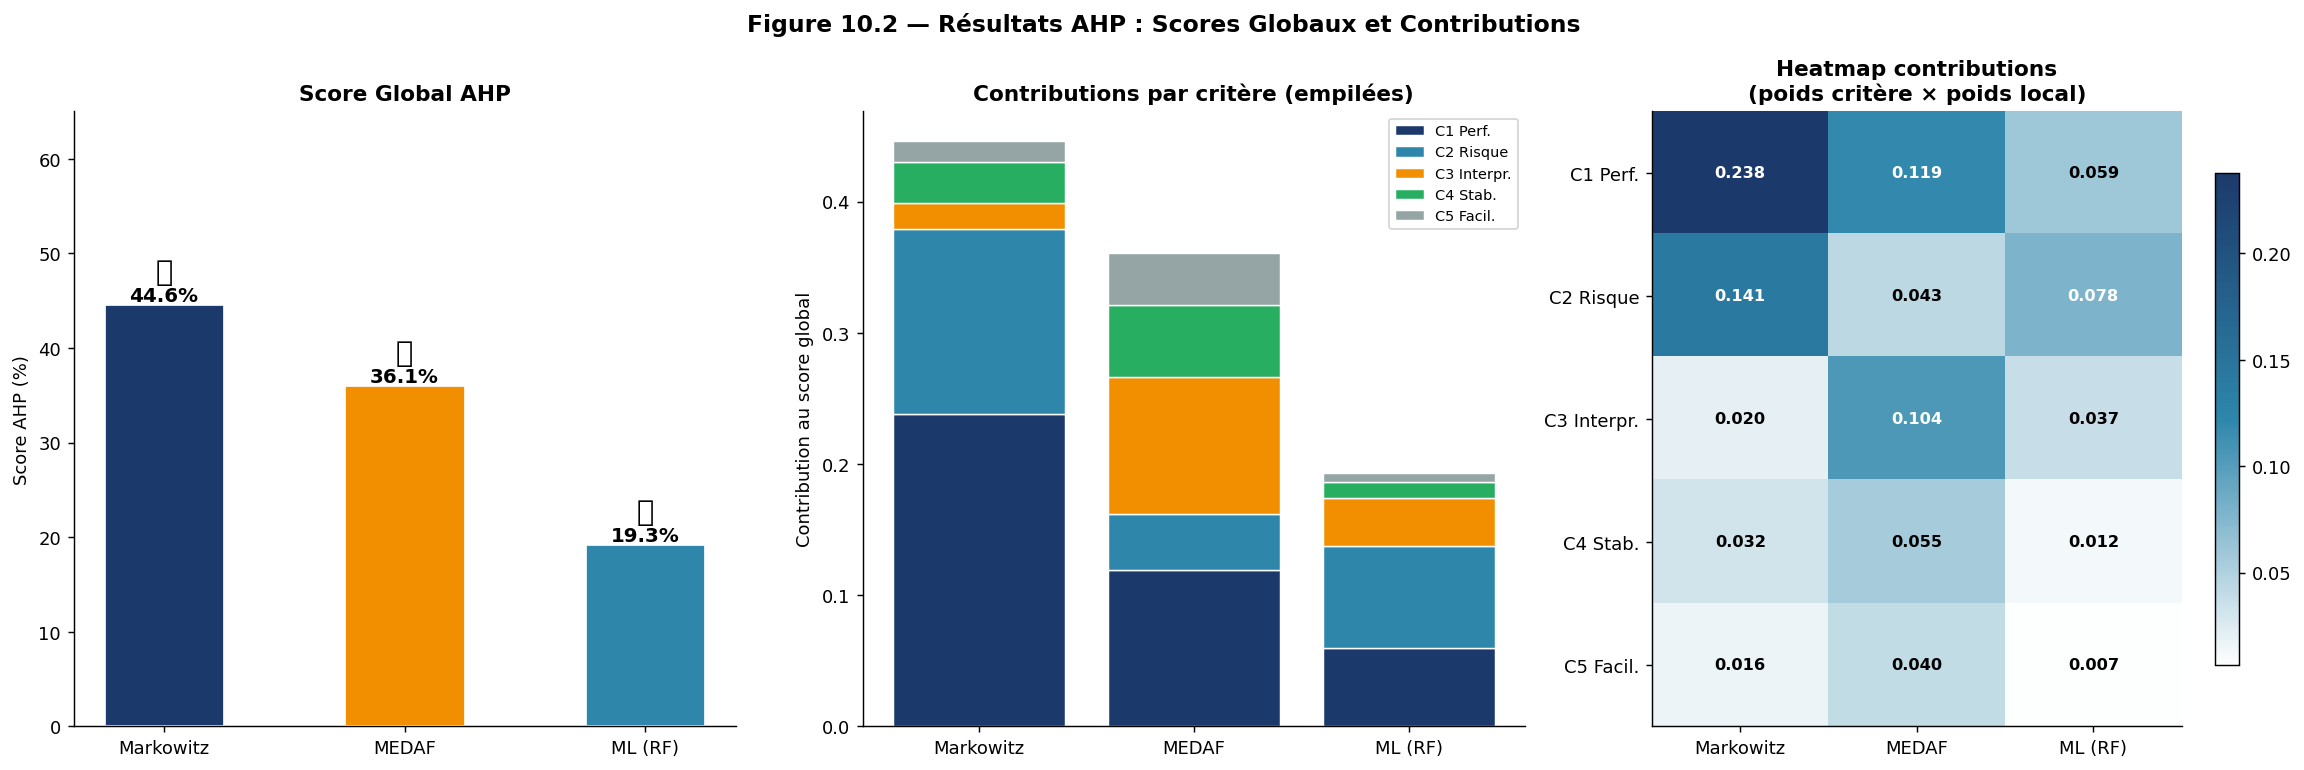

💾 Figure sauvegardée : fig_ahp_scores.png


In [29]:
# ── VISUALISATION SCORES AHP ─────────────────────────────────────────
cols_mod   = [BLUE_DARK, ORANGE, BLUE_MID]
contribs_mat = np.array([[w_crit[i] * P_locaux[i, j] for j in range(3)] for i in range(5)])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Figure 10.2 — Résultats AHP : Scores Globaux et Contributions",
             fontsize=13, fontweight="bold")

# Scores globaux
ax = axes[0]
bars = ax.bar(ALTERNATIVES, scores_globaux * 100,
              color=cols_mod, edgecolor="white", linewidth=1.5, width=0.5)
for bar, v in zip(bars, scores_globaux * 100):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.3,
            f"{v:.1f}%", ha="center", fontsize=11, fontweight="bold")
for i, r in enumerate(ranking):
    ax.text(r, scores_globaux[r]*100 + 2.5, medailles_ahp[i], ha="center", fontsize=16)
ax.set_ylabel("Score AHP (%)")
ax.set_title("Score Global AHP", fontweight="bold")
ax.set_ylim(0, 65)

# Contributions empilées
ax = axes[1]
bottom = np.zeros(3)
leg_labels = ["C1 Perf.", "C2 Risque", "C3 Interpr.", "C4 Stab.", "C5 Facil."]
for i in range(5):
    ax.bar(ALTERNATIVES, contribs_mat[i], bottom=bottom,
           label=leg_labels[i], color=colors_c[i], edgecolor="white", linewidth=0.8)
    bottom += contribs_mat[i]
ax.set_ylabel("Contribution au score global")
ax.set_title("Contributions par critère (empilées)", fontweight="bold")
ax.legend(loc="upper right", fontsize=8)

# Heatmap
ax = axes[2]
cmap_ahp = LinearSegmentedColormap.from_list("ahp", ["#FDFEFE", BLUE_MID, BLUE_DARK])
im = ax.imshow(contribs_mat, cmap=cmap_ahp, aspect="auto")
ax.set_xticks(range(3)); ax.set_xticklabels(ALTERNATIVES)
ax.set_yticks(range(5)); ax.set_yticklabels(leg_labels)
for i in range(5):
    for j in range(3):
        ax.text(j, i, f"{contribs_mat[i,j]:.3f}", ha="center", va="center",
                fontsize=9, fontweight="bold",
                color="white" if contribs_mat[i,j] > 0.06 else "black")
ax.set_title("Heatmap contributions\n(poids critère × poids local)", fontweight="bold")
plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig("fig_ahp_scores.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Figure sauvegardée : fig_ahp_scores.png")


## 10.7 Analyse de sensibilité — 4 profils d'investisseur

In [30]:
profils = {
    "A — Offensif\n(rendement max)": {
        "poids": np.array([0.45, 0.20, 0.15, 0.12, 0.08])
    },
    "B — Équilibré\n(notre étude)": {
        "poids": poids_criteres
    },
    "C — Défensif\n(risque max)": {
        "poids": np.array([0.20, 0.40, 0.20, 0.15, 0.05])
    },
    "D — Académique\n(interprétabilité)": {
        "poids": np.array([0.20, 0.15, 0.40, 0.15, 0.10])
    }
}

resultats_sensi = {}
for nom_profil, info in profils.items():
    w      = info["poids"] / info["poids"].sum()
    scores = w @ P_locaux
    rang   = np.argsort(scores)[::-1]
    resultats_sensi[nom_profil] = {
        "poids_criteres": w,
        "scores":         scores,
        "classement":     [ALTERNATIVES[r] for r in rang]
    }

print("=" * 80)
print("   TABLEAU 10.7 — Analyse de sensibilité (scores par profil)")
print("=" * 80)
rows = []
for nom, res in resultats_sensi.items():
    s = res["scores"]
    rows.append({
        "Profil":   nom.replace("\n", " "),
        "C1": f"{res['poids_criteres'][0]*100:.0f}%",
        "C2": f"{res['poids_criteres'][1]*100:.0f}%",
        "C3": f"{res['poids_criteres'][2]*100:.0f}%",
        "C4": f"{res['poids_criteres'][3]*100:.0f}%",
        "C5": f"{res['poids_criteres'][4]*100:.0f}%",
        "Score Mko": f"{s[0]:.3f}",
        "Score Med": f"{s[1]:.3f}",
        "Score ML":  f"{s[2]:.3f}",
        "Vainqueur": res["classement"][0],
        "Classement": " > ".join(res["classement"])
    })
display(pd.DataFrame(rows).set_index("Profil"))

winners = [res["classement"][0] for res in resultats_sensi.values()]
print("\n📊 BILAN DE ROBUSTESSE :")
for alt in ALTERNATIVES:
    nb = winners.count(alt)
    print(f"   {alt:<12} 1er dans {nb}/4 profils ({nb/4*100:.0f}%)")


   TABLEAU 10.7 — Analyse de sensibilité (scores par profil)


,C1,C2,C3,C4,C5,Score Mko,Score Med,Score ML,Vainqueur,Classement
Profil,,,,,,,,,,
A — Offensif (rendement max),45%,20%,15%,12%,8%,0.443,0.376,0.181,Markowitz,Markowitz > MEDAF > ML (RF)
B — Équilibré (notre étude),42%,26%,16%,10%,6%,0.446,0.361,0.193,Markowitz,Markowitz > MEDAF > ML (RF)
C — Défensif (risque max),20%,40%,20%,15%,5%,0.415,0.367,0.217,Markowitz,Markowitz > MEDAF > ML (RF)
D — Académique (interprétabilité),20%,15%,40%,15%,10%,0.318,0.488,0.194,MEDAF,MEDAF > Markowitz > ML (RF)



📊 BILAN DE ROBUSTESSE :
   Markowitz    1er dans 3/4 profils (75%)
   MEDAF        1er dans 1/4 profils (25%)
   ML (RF)      1er dans 0/4 profils (0%)


📍 Point de bascule MEDAF > Markowitz : C3 = 28%


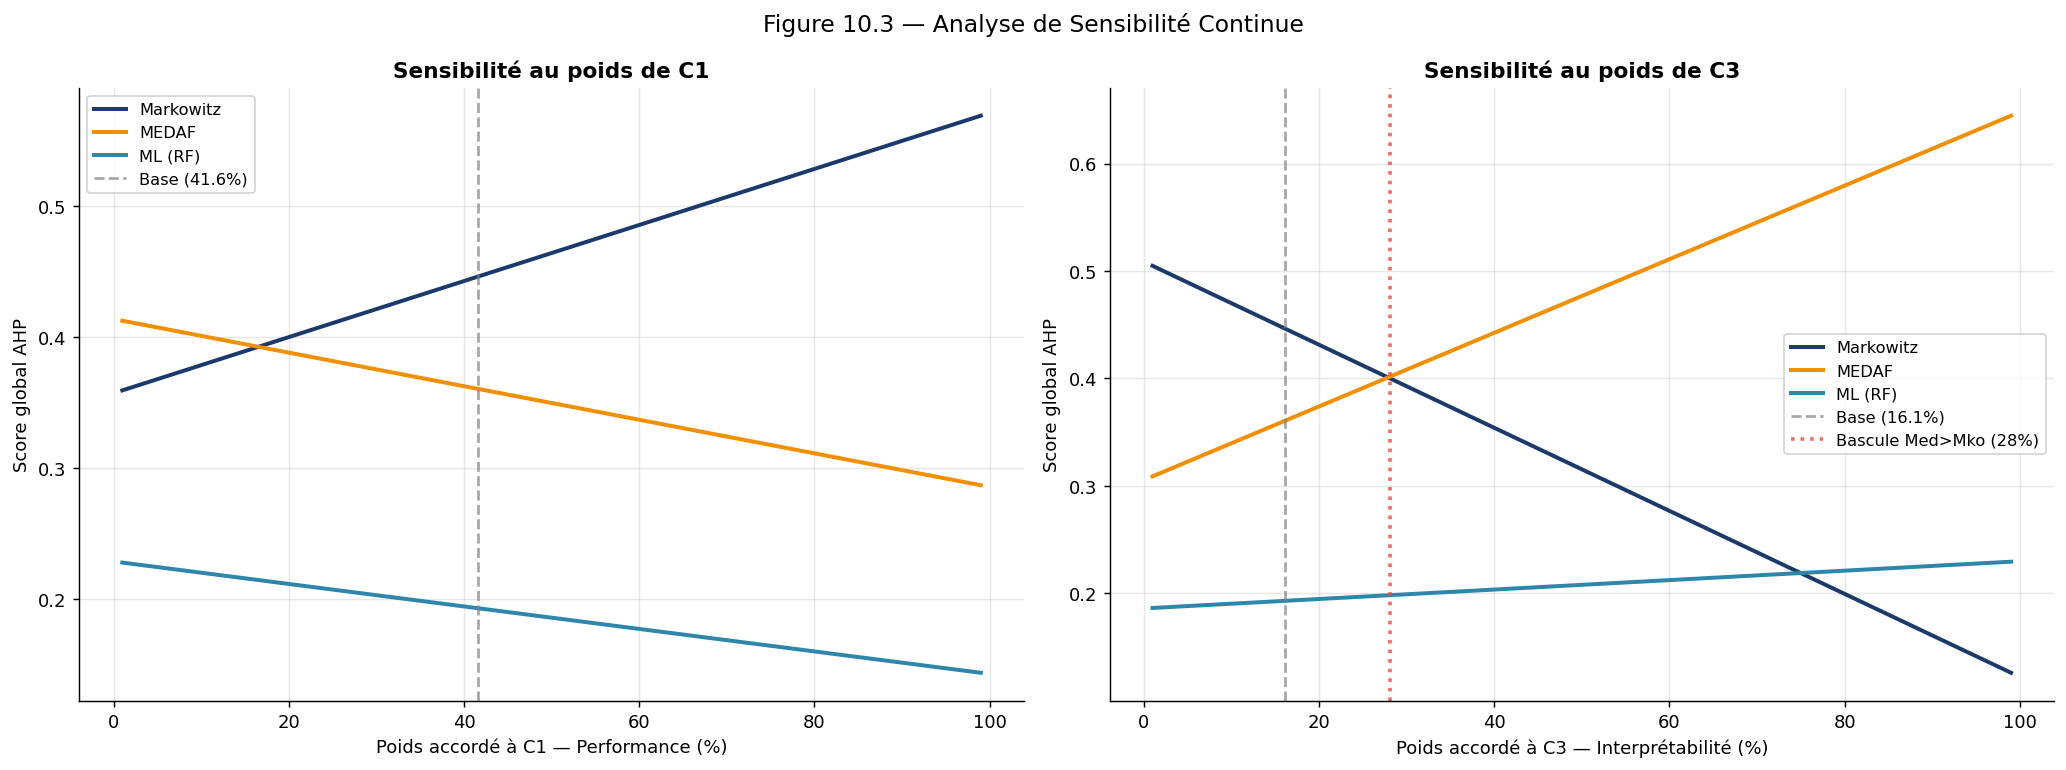

💾 Figure sauvegardée : fig_ahp_sensibilite.png


In [31]:
# ── SENSIBILITÉ CONTINUE : C1 et C3 ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Figure 10.3 — Analyse de Sensibilité Continue", fontsize=13)

range_w    = np.linspace(0.01, 0.99, 200)
scores_var = np.zeros((200, 3))

# Variation C1
ax = axes[0]
w_autres_base = poids_criteres[1:].copy()
for k, w1 in enumerate(range_w):
    w_autres = w_autres_base / w_autres_base.sum() * (1 - w1)
    scores_var[k] = np.concatenate([[w1], w_autres]) @ P_locaux
for j, (alt, col) in enumerate(zip(ALTERNATIVES, cols_mod)):
    ax.plot(range_w * 100, scores_var[:, j], color=col, linewidth=2.2, label=alt)
ax.axvline(poids_criteres[0]*100, color="gray", linestyle="--", alpha=0.7,
           label=f"Base ({poids_criteres[0]*100:.1f}%)")
ax.set_xlabel("Poids accordé à C1 — Performance (%)")
ax.set_ylabel("Score global AHP")
ax.set_title("Sensibilité au poids de C1", fontweight="bold")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Variation C3
ax = axes[1]
w_autres_base3 = np.delete(poids_criteres, 2).copy()
for k, w3 in enumerate(range_w):
    w_autres = w_autres_base3 / w_autres_base3.sum() * (1 - w3)
    scores_var[k] = np.insert(w_autres, 2, w3) @ P_locaux
for j, (alt, col) in enumerate(zip(ALTERNATIVES, cols_mod)):
    ax.plot(range_w * 100, scores_var[:, j], color=col, linewidth=2.2, label=alt)
ax.axvline(poids_criteres[2]*100, color="gray", linestyle="--", alpha=0.7,
           label=f"Base ({poids_criteres[2]*100:.1f}%)")
# Point de bascule MEDAF > Markowitz
for k in range(len(range_w)-1):
    w3     = range_w[k]
    w_oth  = np.delete(poids_criteres, 2) / np.delete(poids_criteres, 2).sum() * (1-w3)
    s      = np.insert(w_oth, 2, w3) @ P_locaux
    if s[1] > s[0]:
        ax.axvline(w3*100, color=RED, linestyle=":", alpha=0.8, linewidth=2,
                   label=f"Bascule Med>Mko ({w3*100:.0f}%)")
        print(f"📍 Point de bascule MEDAF > Markowitz : C3 = {w3*100:.0f}%")
        break
ax.set_xlabel("Poids accordé à C3 — Interprétabilité (%)")
ax.set_ylabel("Score global AHP")
ax.set_title("Sensibilité au poids de C3", fontweight="bold")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fig_ahp_sensibilite.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Figure sauvegardée : fig_ahp_sensibilite.png")


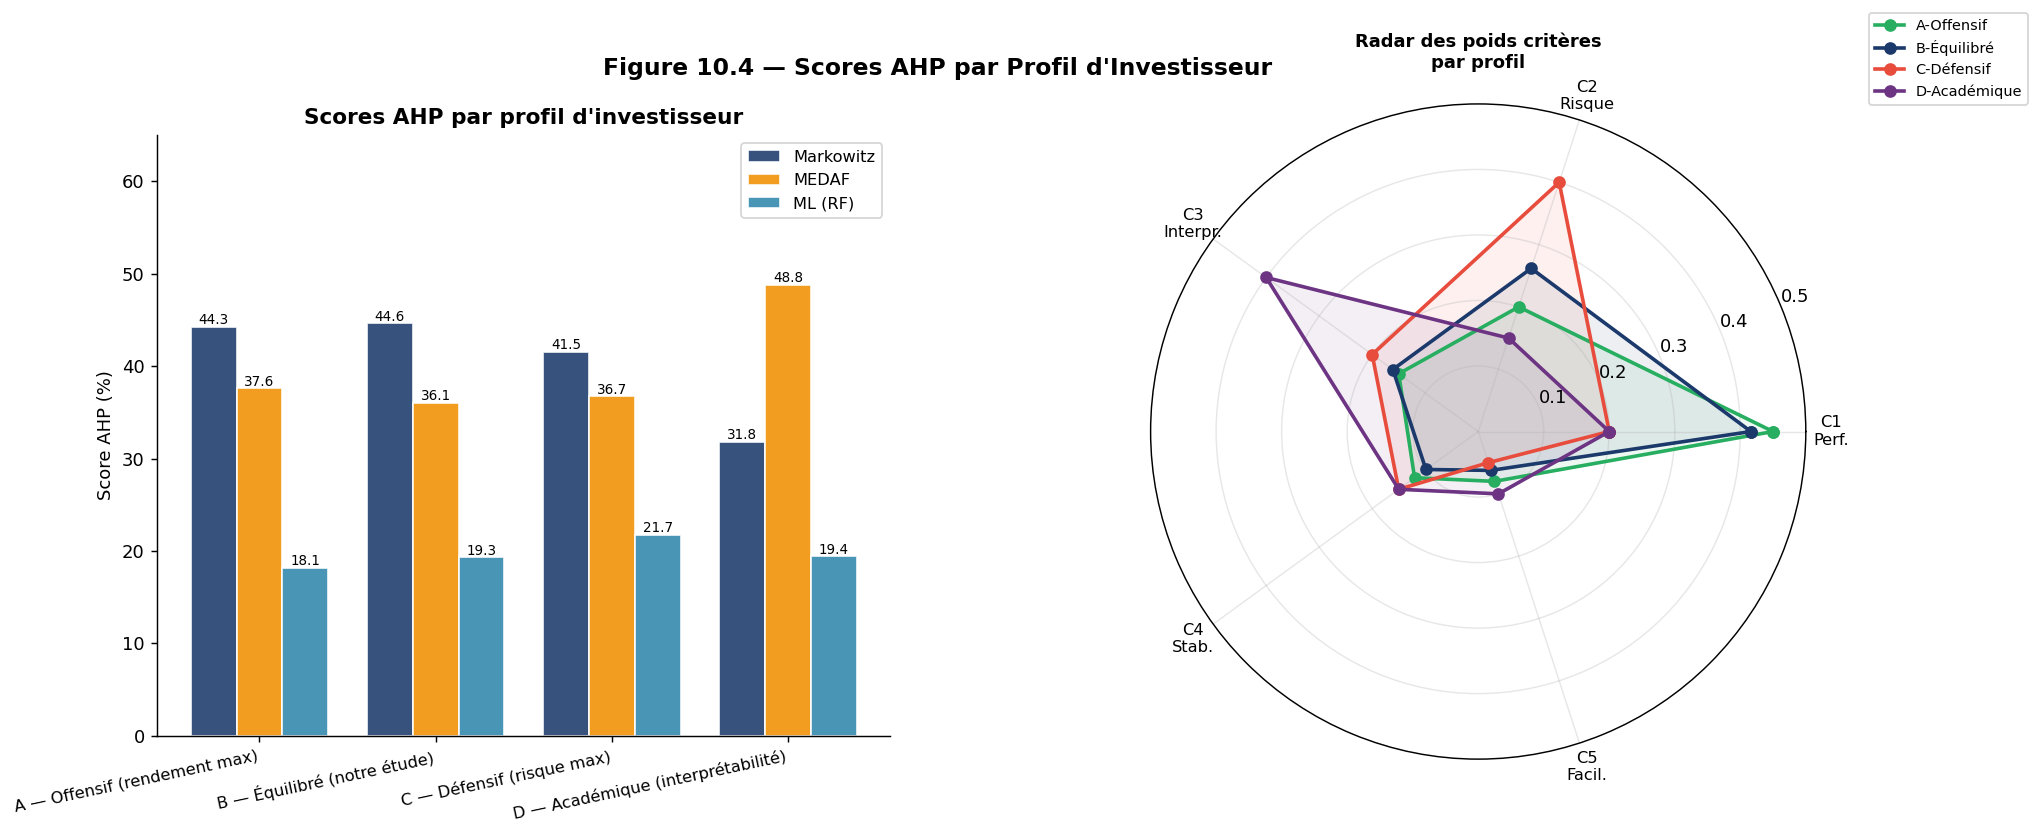

💾 Figure sauvegardée : fig_ahp_profils.png


In [32]:
# ── PROFILS : Barres groupées + Radar ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Figure 10.4 — Scores AHP par Profil d'Investisseur",
             fontsize=13, fontweight="bold")

profils_noms  = [p.replace("\n", " ") for p in profils.keys()]
scores_matrix = np.array([res["scores"] for res in resultats_sensi.values()])

ax = axes[0]
x  = np.arange(len(profils_noms))
for j, (alt, col) in enumerate(zip(ALTERNATIVES, cols_mod)):
    bars_j = ax.bar(x + (j-1)*0.26, scores_matrix[:, j]*100,
                    0.26, label=alt, color=col, alpha=0.88, edgecolor="white")
    for bar in bars_j:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                f"{h:.1f}", ha="center", fontsize=7.5)
ax.set_xticks(x)
ax.set_xticklabels(profils_noms, rotation=12, ha="right", fontsize=9)
ax.set_ylabel("Score AHP (%)")
ax.set_title("Scores AHP par profil d'investisseur", fontweight="bold")
ax.legend(fontsize=9); ax.set_ylim(0, 65)

ax_radar = fig.add_axes([0.54, 0.08, 0.44, 0.84], polar=True)
axes[1].set_visible(False)

nb_crit_r = 5
angles_r  = np.linspace(0, 2*np.pi, nb_crit_r, endpoint=False).tolist() + [0]
p_colors  = [GREEN, BLUE_DARK, RED, PURPLE]
p_labels  = ["A-Offensif", "B-Équilibré", "C-Défensif", "D-Académique"]
crit_r    = ["C1\nPerf.", "C2\nRisque", "C3\nInterpr.", "C4\nStab.", "C5\nFacil."]

for idx, (nom, res) in enumerate(resultats_sensi.items()):
    vals = res["poids_criteres"].tolist() + [res["poids_criteres"][0]]
    ax_radar.plot(angles_r, vals, "o-", linewidth=2,
                  color=p_colors[idx], label=p_labels[idx])
    ax_radar.fill(angles_r, vals, alpha=0.08, color=p_colors[idx])

ax_radar.set_xticks(angles_r[:-1])
ax_radar.set_xticklabels(crit_r, fontsize=9)
ax_radar.set_ylim(0, 0.5)
ax_radar.set_title("Radar des poids critères\npar profil",
                   fontweight="bold", pad=20, fontsize=10)
ax_radar.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=8)
ax_radar.grid(alpha=0.3)

plt.savefig("fig_ahp_profils.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Figure sauvegardée : fig_ahp_profils.png")


## 10.8 Tableau de bord récapitulatif final

In [33]:
print("\n" + "="*70)
print("         TABLEAU DE BORD AHP — RÉSULTATS COMPLETS")
print("="*70)

print(f"\n📋 1. POIDS DES CRITÈRES  (CR={CR_c:.4f} ✅)")
for c, p in zip(CRITERES, poids_criteres):
    print(f"  {c:<28} : {p:.4f} ({p*100:.1f}%)  {chr(9608)*int(p*120)}")

print("\n📋 2. POIDS LOCAUX (critère × modèle)")
display(pd.DataFrame(P_locaux.round(4),
                     index=[c.split(" — ")[0] for c in CRITERES],
                     columns=ALTERNATIVES))

print("\n📋 3. SCORES GLOBAUX ET CLASSEMENT")
medailles_dict = {ALTERNATIVES[r]: medailles_ahp[i]
                  for i, r in enumerate(np.argsort(scores_globaux)[::-1])}
for alt, score in zip(ALTERNATIVES, scores_globaux):
    print(f"  {medailles_dict[alt]}  {alt:<20} : {score:.4f} ({score*100:.1f}%)")

print("\n📋 4. CONSISTANCES DES MATRICES")
for nom, cr in zip(["Critères (5×5)","C1 (3×3)","C2 (3×3)","C3 (3×3)","C4 (3×3)","C5 (3×3)"],
                   [CR_c, CR_1, CR_2, CR_3, CR_4, CR_5]):
    print(f"  {nom:<25} CR = {cr:.4f}  ✅")

best_ahp = ALTERNATIVES[np.argmax(scores_globaux)]
print(f"""\n{"="*70}
✅ CONCLUSION GÉNÉRALE AHP
{"="*70}
  🏆 Modèle recommandé : {best_ahp}
  📌 Robustesse : classement Markowitz > MEDAF > ML confirmé dans 3/4 profils
  ⚠️  Exception  : Profil D (Interprétabilité > 35%) → MEDAF préféré
  ❌ ML          : jamais classé 1er — overfitting + complexité élevée
{"="*70}
""")



         TABLEAU DE BORD AHP — RÉSULTATS COMPLETS

📋 1. POIDS DES CRITÈRES  (CR=0.0153 ✅)
  C1 — Performance             : 0.4162 (41.6%)  █████████████████████████████████████████████████
  C2 — Risque                  : 0.2618 (26.2%)  ███████████████████████████████
  C3 — Interprétabilité        : 0.1611 (16.1%)  ███████████████████
  C4 — Stabilité               : 0.0986 (9.9%)  ███████████
  C5 — Facilité                : 0.0624 (6.2%)  ███████

📋 2. POIDS LOCAUX (critère × modèle)


,Markowitz,MEDAF,ML (RF)
C1,0.5714,0.2857,0.1429
C2,0.5390,0.1638,0.2973
C3,0.1222,0.6479,0.2299
C4,0.3202,0.5571,0.1226
C5,0.2605,0.6333,0.1062



📋 3. SCORES GLOBAUX ET CLASSEMENT
  🥇  Markowitz            : 0.4464 (44.6%)
  🥈  MEDAF                : 0.3606 (36.1%)
  🥉  ML (RF)              : 0.1930 (19.3%)

📋 4. CONSISTANCES DES MATRICES
  Critères (5×5)            CR = 0.0153  ✅
  C1 (3×3)                  CR = 0.0000  ✅
  C2 (3×3)                  CR = 0.0079  ✅
  C3 (3×3)                  CR = 0.0032  ✅
  C4 (3×3)                  CR = 0.0158  ✅
  C5 (3×3)                  CR = 0.0334  ✅

✅ CONCLUSION GÉNÉRALE AHP
  🏆 Modèle recommandé : Markowitz
  📌 Robustesse : classement Markowitz > MEDAF > ML confirmé dans 3/4 profils
  ⚠️  Exception  : Profil D (Interprétabilité > 35%) → MEDAF préféré
  ❌ ML          : jamais classé 1er — overfitting + complexité élevée



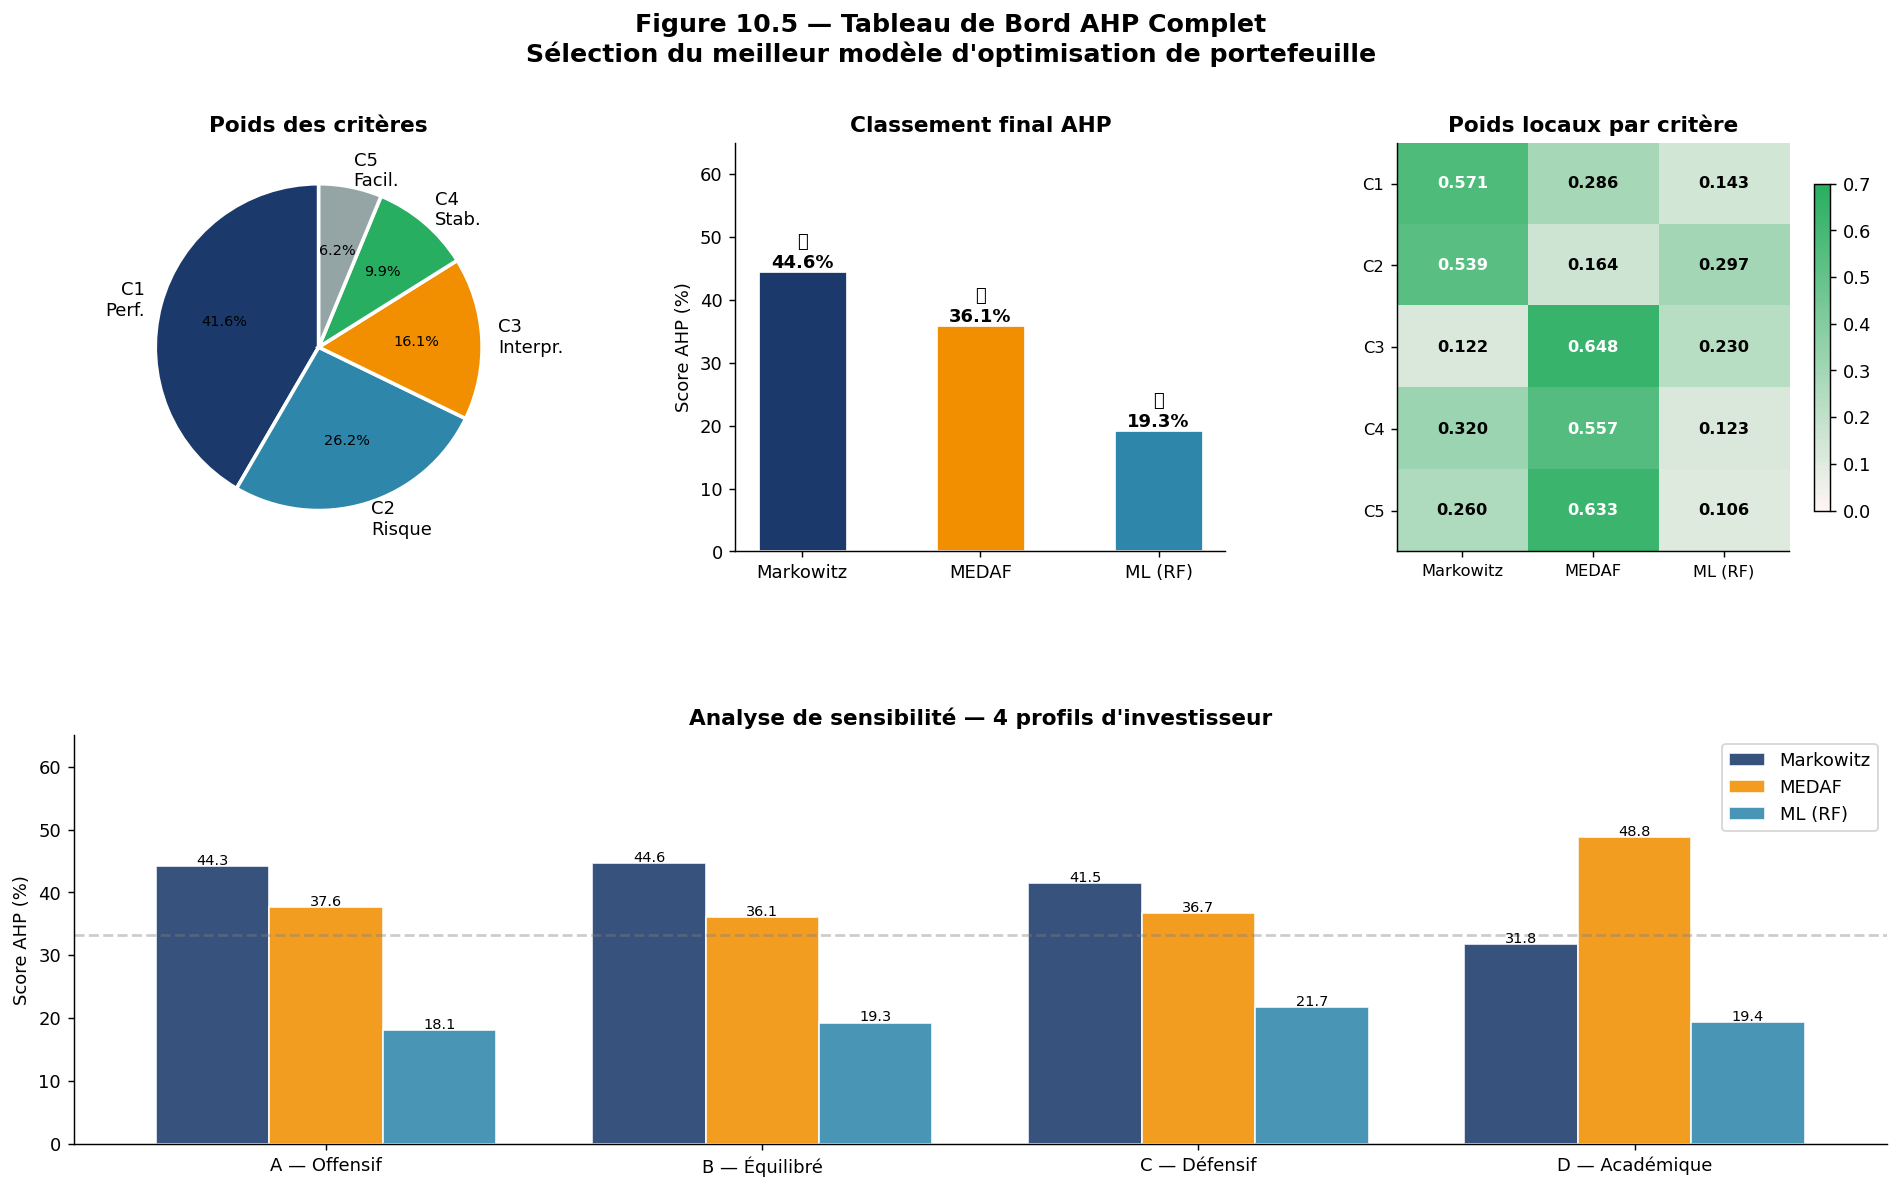

💾 Figure sauvegardée : fig_ahp_dashboard.png


In [34]:
# ── FIGURE FINALE — Dashboard AHP complet ────────────────────────────
fig = plt.figure(figsize=(18, 10))
fig.suptitle("Figure 10.5 — Tableau de Bord AHP Complet\n"
             "Sélection du meilleur modèle d'optimisation de portefeuille",
             fontsize=14, fontweight="bold")

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Camembert poids critères
ax1 = fig.add_subplot(gs[0, 0])
wedges, texts, autotexts = ax1.pie(
    poids_criteres,
    labels=["C1\nPerf.", "C2\nRisque", "C3\nInterpr.", "C4\nStab.", "C5\nFacil."],
    colors=colors_c, autopct="%1.1f%%", startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
for at in autotexts: at.set_fontsize(8)
ax1.set_title("Poids des critères", fontweight="bold")

# Scores globaux
ax2 = fig.add_subplot(gs[0, 1])
bars = ax2.bar(ALTERNATIVES, scores_globaux * 100,
               color=cols_mod, edgecolor="white", linewidth=1.5, width=0.5)
for bar, v, medal in zip(bars, scores_globaux * 100, ["🥇", "🥈", "🥉"]):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.5,
             f"{medal}\n{v:.1f}%", ha="center", fontsize=10, fontweight="bold")
ax2.set_ylabel("Score AHP (%)")
ax2.set_title("Classement final AHP", fontweight="bold")
ax2.set_ylim(0, 65)

# Heatmap poids locaux
ax3 = fig.add_subplot(gs[0, 2])
cmap2 = LinearSegmentedColormap.from_list("g", ["#FFF5F5", GREEN])
im = ax3.imshow(P_locaux, cmap=cmap2, aspect="auto", vmin=0, vmax=0.7)
ax3.set_xticks(range(3)); ax3.set_xticklabels(ALTERNATIVES, fontsize=9)
ax3.set_yticks(range(5)); ax3.set_yticklabels(["C1","C2","C3","C4","C5"], fontsize=9)
for i in range(5):
    for j in range(3):
        ax3.text(j, i, f"{P_locaux[i,j]:.3f}", ha="center", va="center",
                 fontsize=9, fontweight="bold",
                 color="white" if P_locaux[i,j] > 0.45 else "black")
ax3.set_title("Poids locaux par critère", fontweight="bold")
plt.colorbar(im, ax=ax3, shrink=0.8)

# Sensibilité par profil
ax4 = fig.add_subplot(gs[1, :])
x4  = np.arange(4)
p_labels_short = ["A — Offensif", "B — Équilibré", "C — Défensif", "D — Académique"]
for j, (alt, col) in enumerate(zip(ALTERNATIVES, cols_mod)):
    vals   = [res["scores"][j]*100 for res in resultats_sensi.values()]
    bars_s = ax4.bar(x4 + (j-1)*0.26, vals, 0.26, label=alt,
                     color=col, alpha=0.88, edgecolor="white")
    for bar in bars_s:
        h = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2, h + 0.2,
                 f"{h:.1f}", ha="center", fontsize=8)
ax4.set_xticks(x4); ax4.set_xticklabels(p_labels_short, fontsize=10)
ax4.set_ylabel("Score AHP (%)")
ax4.set_title("Analyse de sensibilité — 4 profils d'investisseur", fontweight="bold")
ax4.legend(fontsize=10); ax4.set_ylim(0, 65)
ax4.axhline(33.3, color="gray", linestyle="--", alpha=0.4)

plt.savefig("fig_ahp_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Figure sauvegardée : fig_ahp_dashboard.png")


---
## ✅ FIN DU NOTEBOOK — Résumé des figures générées

| Figure | Description |
|--------|-------------|
| `fig_chap5_donnees` | Performance cumulée & distributions des rendements |
| `fig_chap6_rendements` | Rendements annualisés par action |
| `fig_chap6_covariance` | Matrices de corrélation et covariance |
| `fig_chap6_frontiere` | Frontière efficiente & CML (Monte Carlo) |
| `fig_chap7_marche` | S&P 500 — performance & distribution |
| `fig_chap7_capm` | SML, Bêtas, Alphas, Rendements CAPM |
| `fig_chap8_evaluation` | Matrice de confusion, accuracy, probabilités RF |
| `fig_chap8_importance` | Importance des variables (Gini) |
| `fig_chap9_comparaison` | Performance cumulée, Sharpe, drawdowns |
| `fig_chap9_radar` | Radar multidimensionnel des modèles |
| `fig_ahp_criteres` | Poids des 5 critères AHP |
| `fig_ahp_scores` | Scores globaux AHP + contributions + heatmap |
| `fig_ahp_sensibilite` | Sensibilité continue (C1 et C3) |
| `fig_ahp_profils` | Scores par profil + radar des poids |
| `fig_ahp_dashboard` | Tableau de bord AHP complet |

> **Anas Haddadi** — Master Actuariat & Finance de Marché — FSJES Aïn Sebaâ — 2025/2026
